# Project: Transformer를 활용한 한국어 챗봇 만들기

## 프로젝트 개요

이번 프로젝트에서는 한국어 질문과 답변 데이터로 Transformer 기반 챗봇을 구현한다.

기존에 학습한 영어-스페인어 번역 모델과 마찬가지로 질문을 Encoder 입력으로 사용하고, 답변을 Decoder 출력으로 사용한다. 질문과 답변이 모두 한국어로 구성되어 있으므로 하나의 단어 사전과 임베딩 레이어를 공유한다.

또한 주어진 데이터의 수가 약 1만 개로 비교적 적기 때문에 한국어 Word2Vec 임베딩을 활용한 Lexical Substitution 방식의 데이터 증강을 적용한다. 원본 데이터, 질문 증강 데이터, 답변 증강 데이터를 결합하여 약 3만 개의 학습 데이터를 구축한다.

## 프로젝트 진행 과정

1. 한국어 챗봇 데이터 불러오기
2. 문장 정제
3. MeCab 형태소 분석기를 이용한 토큰화
4. Word2Vec 기반 Lexical Substitution 데이터 증강
5. 단어 사전 구축 및 텐서 변환
6. Transformer 모델 구현 및 학습
7. 챗봇 답변 생성
8. BLEU Score를 이용한 정량 평가
9. 결과 분석 및 회고

## 프로젝트 목표

- 질문과 답변 데이터의 병렬 관계를 유지하며 전처리한다.
- 중복 데이터와 지나치게 긴 문장을 제거한다.
- Lexical Substitution을 적용하여 약 3만 개의 데이터를 구축한다.
- 과적합을 줄일 수 있는 Transformer 하이퍼파라미터를 설정한다.
- 주어진 예문에 대해 자연스러운 한국어 답변을 생성한다.
- BLEU Score와 실제 출력 문장을 함께 활용해 챗봇 성능을 평가한다.

## 0-1. 라이브러리 및 실행 환경 확인

프로젝트에서 사용할 주요 라이브러리의 버전과 GPU 사용 가능 여부를 확인한다.

이번 프로젝트에서는 다음 라이브러리를 사용한다.

- NumPy: 배열 및 수치 연산
- Pandas: CSV 데이터 처리
- PyTorch: Transformer 모델 구현 및 학습
- NLTK: BLEU Score 계산
- Gensim: 한국어 Word2Vec 모델 로드 및 데이터 증강
- KoNLPy: MeCab 형태소 분석기 사용

In [2]:
!pip install -q gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.5 MB/s eta 0:00:00


In [3]:
import gensim
import nltk

print("Gensim version:", gensim.__version__)
print("NLTK version:", nltk.__version__)
print("설치 완료")

Gensim version: 4.4.0
NLTK version: 3.9.1
설치 완료


In [4]:
import os
import re
import math
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import nltk
import gensim

from tqdm.notebook import tqdm
from torch.utils.data import TensorDataset, DataLoader
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

warnings.filterwarnings("ignore")

print("NumPy version :", np.__version__)
print("Pandas version:", pd.__version__)
print("PyTorch version:", torch.__version__)
print("NLTK version  :", nltk.__version__)
print("Gensim version:", gensim.__version__)

NumPy version : 2.0.2
Pandas version: 2.2.2
PyTorch version: 2.11.0+cu128
NLTK version  : 3.9.1
Gensim version: 4.4.0


In [5]:
# GPU 사용 가능 여부 확인

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
    print(
        "GPU 메모리:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    print("현재 CPU 환경입니다.")

사용 장치: cuda
GPU 이름: Tesla T4
GPU 메모리: 14.56 GB


# Step 1. 챗봇 데이터 다운로드 및 불러오기

이번 프로젝트에서는 `Chatbot_data` 저장소의 한국어 질문-답변 데이터를 사용한다.

데이터 파일은 `ChatbotData.csv`이며 주요 열은 다음과 같다.

- `Q`: 사용자의 질문
- `A`: 질문에 대한 답변
- `label`: 대화 감정 또는 유형을 나타내는 레이블

이번 프로젝트에서는 질문과 답변 생성이 목적이므로 `Q`와 `A` 열을 사용한다.

CSV 파일을 Pandas로 불러온 뒤 질문은 `questions`, 답변은 `answers` 변수에 각각 저장한다. 이후 질문과 답변의 개수, 결측치, 중복 여부를 확인한다.

In [6]:
import os
import urllib.request

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "songys/Chatbot_data/master/ChatbotData.csv"
)

DATA_PATH = "/content/ChatbotData.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("데이터 다운로드 완료")
else:
    print("이미 데이터 파일이 존재합니다.")

print("데이터 경로:", DATA_PATH)
print("파일 존재 여부:", os.path.exists(DATA_PATH))
print("파일 크기:", round(os.path.getsize(DATA_PATH) / 1024, 2), "KB")

데이터 다운로드 완료
데이터 경로: /content/ChatbotData.csv
파일 존재 여부: True
파일 크기: 868.99 KB


## 1-2. CSV 데이터 확인

다운로드한 CSV 파일을 Pandas의 `read_csv()` 함수로 불러온다.

먼저 데이터 크기와 열 이름을 확인하고, 상위 데이터 일부를 출력하여 질문과 답변이 정상적으로 읽혔는지 확인한다.

In [7]:
chatbot_df = pd.read_csv(DATA_PATH)

print("데이터 크기:", chatbot_df.shape)
print("열 이름:", chatbot_df.columns.tolist())

display(chatbot_df.head())

데이터 크기: (11823, 3)
열 이름: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 1-3. 질문과 답변 데이터 분리

CSV의 `Q` 열은 사용자의 질문으로, `A` 열은 챗봇의 정답 답변으로 사용한다.

두 열을 각각 문자열 리스트로 변환하여 다음 변수에 저장한다.

- `questions`: Encoder의 입력으로 사용할 질문
- `answers`: Decoder의 정답으로 사용할 답변

동일한 행에 있는 질문과 답변이 하나의 학습 쌍이므로 두 리스트의 순서와 길이를 반드시 동일하게 유지해야 한다.

In [8]:
questions = chatbot_df["Q"].astype(str).tolist()
answers = chatbot_df["A"].astype(str).tolist()

print("질문 개수:", len(questions))
print("답변 개수:", len(answers))

assert len(questions) == len(answers), \
    "질문과 답변의 개수가 다릅니다."

print("질문과 답변의 개수가 일치합니다.")

질문 개수: 11823
답변 개수: 11823
질문과 답변의 개수가 일치합니다.


In [9]:
for idx in range(10):
    print(f"[데이터 {idx + 1}]")
    print("질문:", questions[idx])
    print("답변:", answers[idx])
    print("-" * 60)

[데이터 1]
질문: 12시 땡!
답변: 하루가 또 가네요.
------------------------------------------------------------
[데이터 2]
질문: 1지망 학교 떨어졌어
답변: 위로해 드립니다.
------------------------------------------------------------
[데이터 3]
질문: 3박4일 놀러가고 싶다
답변: 여행은 언제나 좋죠.
------------------------------------------------------------
[데이터 4]
질문: 3박4일 정도 놀러가고 싶다
답변: 여행은 언제나 좋죠.
------------------------------------------------------------
[데이터 5]
질문: PPL 심하네
답변: 눈살이 찌푸려지죠.
------------------------------------------------------------
[데이터 6]
질문: SD카드 망가졌어
답변: 다시 새로 사는 게 마음 편해요.
------------------------------------------------------------
[데이터 7]
질문: SD카드 안돼
답변: 다시 새로 사는 게 마음 편해요.
------------------------------------------------------------
[데이터 8]
질문: SNS 맞팔 왜 안하지ㅠㅠ
답변: 잘 모르고 있을 수도 있어요.
------------------------------------------------------------
[데이터 9]
질문: SNS 시간낭비인 거 아는데 매일 하는 중
답변: 시간을 정하고 해보세요.
------------------------------------------------------------
[데이터 10]
질문: SNS 시간낭비인데 자꾸 보게됨
답변: 시간을 정하고 해보세요.
--------------------

## 1-5. 결측치 확인

질문 또는 답변이 비어 있는 데이터는 정상적인 질문-답변 학습 쌍으로 사용할 수 없다.

따라서 `Q`, `A` 열에 결측값이 존재하는지 확인한다. 결측값이 있다면 해당 행 전체를 제거하여 질문과 답변의 대응 관계가 흐트러지지 않도록 한다.

In [10]:
print("열별 결측치 개수")
print(chatbot_df[["Q", "A"]].isnull().sum())

열별 결측치 개수
Q    0
A    0
dtype: int64


In [11]:
chatbot_df = chatbot_df.dropna(
    subset=["Q", "A"]
).reset_index(drop=True)

questions = chatbot_df["Q"].astype(str).tolist()
answers = chatbot_df["A"].astype(str).tolist()

print("결측치 제거 후 데이터 수:", len(chatbot_df))

assert len(questions) == len(answers)

결측치 제거 후 데이터 수: 11823


## 1-6. 빈 문자열 데이터 제거

결측값은 아니지만 공백만 들어 있는 질문이나 답변이 있을 수 있다.

각 문자열의 양쪽 공백을 제거한 뒤 길이가 0인 행을 제거한다. 질문만 제거하거나 답변만 제거하면 데이터 쌍이 깨지므로 반드시 DataFrame의 행 단위로 제거한다.

In [12]:
chatbot_df["Q"] = chatbot_df["Q"].astype(str).str.strip()
chatbot_df["A"] = chatbot_df["A"].astype(str).str.strip()

empty_mask = (
    chatbot_df["Q"].eq("")
    | chatbot_df["A"].eq("")
)

print("빈 질문 또는 답변이 있는 행:", empty_mask.sum())

chatbot_df = chatbot_df[
    ~empty_mask
].reset_index(drop=True)

questions = chatbot_df["Q"].tolist()
answers = chatbot_df["A"].tolist()

print("빈 문자열 제거 후 데이터 수:", len(chatbot_df))

assert len(questions) == len(answers)

빈 질문 또는 답변이 있는 행: 0
빈 문자열 제거 후 데이터 수: 11823


## 1-7. 질문과 답변의 중복 현황 확인

프로젝트 요구사항에서는 토큰화 과정에서 중복 질문과 중복 답변을 제거해야 한다.

이 단계에서는 데이터를 바로 제거하지 않고, 원본 데이터에 중복 질문과 중복 답변이 얼마나 포함되어 있는지만 확인한다.

중복 제거는 이후 `build_corpus()` 함수에서 질문과 답변의 병렬 관계를 유지하며 수행한다.

In [14]:
question_duplicate_count = chatbot_df["Q"].duplicated().sum()
answer_duplicate_count = chatbot_df["A"].duplicated().sum()
pair_duplicate_count = chatbot_df[["Q", "A"]].duplicated().sum()

print("중복 질문 수:", question_duplicate_count)
print("중복 답변 수:", answer_duplicate_count)
print("완전히 동일한 질문-답변 쌍 수:", pair_duplicate_count)

중복 질문 수: 161
중복 답변 수: 4044
완전히 동일한 질문-답변 쌍 수: 73


In [15]:
duplicate_questions = chatbot_df[
    chatbot_df["Q"].duplicated(keep=False)
].sort_values("Q")

print("중복 질문 예시")
display(duplicate_questions.head(10))

중복 질문 예시


,Q,A,label
5316,2년 가량의 연애,안 좋은 기억보다 좋은 기억이 더 많았으면 좋겠네요.,1
8868,2년 가량의 연애,딱 잘 만났네요.,2
8901,가을 타나 봐.,외로운 옆구리를 채워보아요.,2
8902,가을 타나 봐.,혼자는 외로운 계절이죠.,2
5439,간단하게 사랑이라는건.,여러번 해도 어려워요.,1
5438,간단하게 사랑이라는건.,간단하지 않은 것.,1
5508,결국 핸드폰 번호 바꿨어,이제 연락 하지 마세요.,1
5509,결국 핸드폰 번호 바꿨어,이제 진짜 잊어요.,1
5510,결국 헤어졌네,더 좋은 사람 만나실 거예요.,1
5511,결국 헤어졌네,또 다른 사랑이 찾아올 거예요.,1


In [16]:
duplicate_answers = chatbot_df[
    chatbot_df["A"].duplicated(keep=False)
].sort_values("A")

print("중복 답변 예시")
display(duplicate_answers.head(10))

중복 답변 예시


,Q,A,label
1918,반배정 망했어,1년 힘내요.,0
1919,반배정부터 올해 끝났다.,1년 힘내요.,0
11522,짝녀가 좋아하는거 눈치 1도 못챔.,1은 알게 해야죠.,2
11390,짝남이 내가 좋아하는걸 1도 몰라.,1은 알게 해야죠.,2
5016,한복 맞출까 빌릴까,2번 이상 입을 일이 있으면 맞추세요.,0
5017,한복 빌려도 예쁠까,2번 이상 입을 일이 있으면 맞추세요.,0
1356,뒤척이다 늦잠 자게 되네,30분씩 일찍 자는 습관을 들여보세요.,0
3482,요즘 잠을 늦게 자,30분씩 일찍 자는 습관을 들여보세요.,0
4742,컴터 고장났나봐,AS센터에 맡겨보세요.,0
8359,컴터가 맛이 갔어,AS센터에 맡겨보세요.,1


## 1-8. 원문 문장 길이 확인

아직 형태소 토큰화를 수행하지 않았으므로 우선 공백 기준 단어 수와 문자열 길이를 간단히 확인한다.

이 결과는 이후 토큰 길이 제한을 설정할 때 참고한다. 실제 데이터 제거 기준은 Step 3에서 MeCab 형태소 분석 결과를 기준으로 적용한다.

In [17]:
question_space_lengths = [
    len(sentence.split())
    for sentence in questions
]

answer_space_lengths = [
    len(sentence.split())
    for sentence in answers
]

print("[질문 공백 기준 길이]")
print("최소:", min(question_space_lengths))
print("평균:", np.mean(question_space_lengths))
print("중앙값:", np.median(question_space_lengths))
print("최대:", max(question_space_lengths))

print("\n[답변 공백 기준 길이]")
print("최소:", min(answer_space_lengths))
print("평균:", np.mean(answer_space_lengths))
print("중앙값:", np.median(answer_space_lengths))
print("최대:", max(answer_space_lengths))

[질문 공백 기준 길이]
최소: 1
평균: 3.587414361837097
중앙값: 3.0
최대: 15

[답변 공백 기준 길이]
최소: 1
평균: 3.6936479742874058
중앙값: 3.0
최대: 21


In [18]:
length_check_df = chatbot_df.copy()

length_check_df["Q_space_len"] = (
    length_check_df["Q"]
    .str.split()
    .str.len()
)

length_check_df["A_space_len"] = (
    length_check_df["A"]
    .str.split()
    .str.len()
)

print("공백 기준 질문 길이가 긴 데이터")
display(
    length_check_df
    .sort_values("Q_space_len", ascending=False)
    .head(10)
)

print("공백 기준 답변 길이가 긴 데이터")
display(
    length_check_df
    .sort_values("A_space_len", ascending=False)
    .head(10)
)

공백 기준 질문 길이가 긴 데이터


,Q,A,label,Q_space_len,A_space_len
11810,확실히 좋아하는 데도 관심 있는거 티 안내려고 선톡 안하고 일부러 늦게 보내고 그러...,많이 있어요.,2,15,2
9519,내가 좋아하는 애가 날 좋아하는 것 같으면 갑자기 정 떨어지고 뭔가 싫어짐,어떤 심리일까요.,2,12,2
11011,제가 좋아하는 사람이 맘 잡고 공부해야할 것 같다고 기다려달라는데 제 맘이 안별할까요?,변할 수도 있지만 미리 걱정하지 말아요.,2,12,6
9273,남자들은 여자가 자기 좋아하는 거 알게 되면 어떻게 해? 싫지 않다면 받아줘?,그분도 좋아한다면 받아줄 거예요.,2,12,4
9276,남자들은 좋아하는 여자가 자기보다 능력이 좋은 경우에 아무리 좋아해도 마음 접고 포...,절대 능력만 중요하지 않아요.,2,12,4
11248,좋아하는 오빠가 최근에 연락이 계속 늦거나 이어지지 않는데 그냥 연락 끊어야 할까.,그러는 것이 맘 편할지도 몰라요.,2,12,5
10052,서로 좋아하는 것 같은데 내가 자존심 때문에 자꾸 관심 없는 척하게 돼.,사랑 앞에 자존심은 소용이 없어요.,2,12,5
5567,괜찮은 줄 알았는데 남자가 생겼단 말에 마음이 또 다시 덜컥 내려 앉네,이젠 떠나간 사람 때문에 괴로워 말아요.,1,12,6
5362,4년 연애 후 이별 6개월. 새로운 시작을 하는 전여친. 너무 힘들어.,헤어지면 남이에요. 신경쓰면 더 힘들어져요.,1,11,5
5396,6년을 널 위해 모든걸 바쳤고 니가 떠난후 4년동안 난 미친듯이 살았다.,힘든 시간 잘 버텨냈어요.,1,11,4


공백 기준 답변 길이가 긴 데이터


,Q,A,label,Q_space_len,A_space_len
10258,썸 탈 때 연락문제로 속상한 적 있어?,썸 탈 때는 특히 속상한 것 같아요. 내 맘 같지 않고 아직 내 사람이 아니니까요....,2,7,21
10808,오래 못 가는 연애,연애는 문제가 있으면 문제를 해결 하기 위해 함께 노력하고 그 속에서 더욱 단단해지...,2,4,20
10728,연애는 하기 싫은데 썸은 타고 싶어.,시작하기 전 두근거림을 더 좋아하나 봐요. 아니면 연애에 대한 두려움을 가지고 있을...,2,6,16
10780,오늘 만나기로 했는데 빈손으로 나가?,준비하지 않아도 상관 없다고 생각해요. 필요하다면 화려하지 않고 부담 없는 선물을 ...,2,5,16
9659,랜선 연애 어떻게 생각해?,얼굴을 안 보고 부딪히지도 않아서 제대로 된 연애가 가능하지 않을 수도 있지만 다 ...,2,4,16
9884,사랑에 유효기간이 있을까?,"사랑하는 사람과 함께하는 어제, 오늘, 내일이 각 다른 의미가 있다고 생각하면 유효...",2,3,16
10926,이상적인 연애란?,서로가 전부인 연애가 아니라 서로 부족한 부분을 감싸 안아서 서로를 완전하게 해주는...,2,2,15
9226,나한테 배려해줘서 나도 해주고 싶어,보는 만큼 알게 되고 아는 만큼 좋아할 수 있고 좋아하는 만큼 배려해줄 수 있을 거예요.,2,5,15
9208,나에 대한 관심이 줄어든 거 같아,연인 사이로 발전할 수 있었던 계기를 살펴보면 서로에 대한 관심이 있었기 때문이라는...,2,6,15
10484,어떤 연애 하고 싶어?,서로가 전부인 연애가 아니라 서로 부족한 부분을 감싸 안아서 서로를 완전하게 해주는...,2,4,15


## Step 1 결과

한국어 챗봇 데이터셋을 다운로드하고 질문과 답변을 각각 분리하였다.

또한 다음 항목을 확인하였다.

- 질문과 답변의 전체 개수
- 질문과 답변의 병렬 관계
- 결측값 및 빈 문자열
- 질문 중복, 답변 중복, 질문-답변 쌍 중복
- 공백 기준 문장 길이 분포

중복 데이터와 길이가 긴 문장은 아직 제거하지 않았다. 다음 단계에서 문장 정제 함수를 구현하고, 이후 MeCab 토큰화 결과를 기준으로 중복 및 길이 필터링을 수행한다.

In [19]:
assert "Q" in chatbot_df.columns
assert "A" in chatbot_df.columns
assert len(chatbot_df) > 0
assert len(questions) == len(answers)
assert chatbot_df["Q"].isnull().sum() == 0
assert chatbot_df["A"].isnull().sum() == 0
assert all(isinstance(q, str) for q in questions)
assert all(isinstance(a, str) for a in answers)

print("=" * 60)
print("Step 1 데이터 준비 완료")
print("=" * 60)
print("최종 데이터 수:", len(chatbot_df))
print("질문 데이터 수:", len(questions))
print("답변 데이터 수:", len(answers))
print("첫 번째 질문:", questions[0])
print("첫 번째 답변:", answers[0])

Step 1 데이터 준비 완료
최종 데이터 수: 11823
질문 데이터 수: 11823
답변 데이터 수: 11823
첫 번째 질문: 12시 땡!
첫 번째 답변: 하루가 또 가네요.


# Step 2. 데이터 정제

영문자는 소문자로 변환하고, 한글·영문자·숫자·주요 문장부호를 제외한 불필요한 문자를 제거한다.

질문과 답변에 동일한 전처리 함수를 적용하여 토큰화에 적합한 형태로 정제한다.

In [20]:
def preprocess_sentence(sentence):
    """
    한국어 챗봇 문장 전처리 함수

    1. 문자열로 변환
    2. 영문자를 소문자로 변환
    3. 한글, 영문자, 숫자, 주요 문장부호 외 문자 제거
    4. 연속된 공백을 하나로 통일
    5. 양쪽 공백 제거
    """
    sentence = str(sentence).lower()

    # 허용 문자:
    # 한글, 영어, 숫자, 공백, 기본 문장부호
    sentence = re.sub(
        r"[^가-힣ㄱ-ㅎㅏ-ㅣa-z0-9?.!,~'\"()%+-]",
        " ",
        sentence
    )

    sentence = re.sub(r"\s+", " ", sentence)
    sentence = sentence.strip()

    return sentence


print(preprocess_sentence("안녕하세요!!! 오늘 기분이 GOOD 😊"))
print(preprocess_sentence("  집에   가고 싶어요...  "))

안녕하세요!!! 오늘 기분이 good
집에 가고 싶어요...


In [21]:
# 전체 데이터에 전처리 적용

clean_questions = [
    preprocess_sentence(sentence)
    for sentence in questions
]

clean_answers = [
    preprocess_sentence(sentence)
    for sentence in answers
]

print("전처리 전 질문:", questions[0])
print("전처리 후 질문:", clean_questions[0])

print("\n전처리 전 답변:", answers[0])
print("전처리 후 답변:", clean_answers[0])

assert len(clean_questions) == len(clean_answers)

print("\n전처리 완료:", len(clean_questions), "쌍")

전처리 전 질문: 12시 땡!
전처리 후 질문: 12시 땡!

전처리 전 답변: 하루가 또 가네요.
전처리 후 답변: 하루가 또 가네요.

전처리 완료: 11823 쌍


In [22]:
# 전처리 결과가 빈 문자열인 데이터 확인

empty_indices = [
    idx
    for idx, (question, answer) in enumerate(
        zip(clean_questions, clean_answers)
    )
    if question == "" or answer == ""
]

print("전처리 후 빈 문장이 발생한 데이터 수:", len(empty_indices))

전처리 후 빈 문장이 발생한 데이터 수: 0


In [23]:
 filtered_questions = []
filtered_answers = []

for question, answer in zip(
    clean_questions,
    clean_answers
):
    if question == "" or answer == "":
        continue

    filtered_questions.append(question)
    filtered_answers.append(answer)

clean_questions = filtered_questions
clean_answers = filtered_answers

assert len(clean_questions) == len(clean_answers)

print("빈 문장 제거 후 데이터 수:", len(clean_questions))

빈 문장 제거 후 데이터 수: 11823


# Step 3. MeCab 형태소 분석과 Corpus 구축

KoNLPy의 MeCab 형태소 분석기를 사용해 질문과 답변을 형태소 단위로 분리한다.

다음 조건을 적용한다.

- 전처리된 질문과 답변을 함께 순회한다.
- 토큰 수가 최대 길이를 초과하는 문장은 제외한다.
- 질문이 이전 질문과 중복되면 제외한다.
- 답변이 이전 답변과 중복되면 제외한다.
- 질문과 답변의 병렬 관계를 유지한다.

In [25]:
!pip install -q konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 39.2 MB/s eta 0:00:00


In [31]:
!pip install -q mecab-python3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 15.8 MB/s eta 0:00:00


In [32]:
import MeCab

print("MeCab Python 모듈 로드 완료")

MeCab Python 모듈 로드 완료


In [33]:
!sed -i 's|^dicdir =.*|dicdir = /usr/local/lib/mecab/dic/mecab-ko-dic|' /usr/local/etc/mecabrc

sed: can't read /usr/local/etc/mecabrc: No such file or directory


In [38]:
from pathlib import Path

mecabrc_path = Path("/usr/local/etc/mecabrc")
mecabrc_path.parent.mkdir(parents=True, exist_ok=True)

mecabrc_path.write_text(
    "dicdir = /usr/local/lib/mecab/dic/mecab-ko-dic\n",
    encoding="utf-8"
)

print(mecabrc_path.read_text())

dicdir = /usr/local/lib/mecab/dic/mecab-ko-dic



In [39]:
from pathlib import Path

dic_path = Path("/usr/local/lib/mecab/dic/mecab-ko-dic")

print("mecabrc 존재:", mecabrc_path.exists())
print("사전 폴더 존재:", dic_path.exists())

if dic_path.exists():
    print("사전 파일 일부:", [p.name for p in list(dic_path.iterdir())[:10]])

mecabrc 존재: True
사전 폴더 존재: False


In [40]:
!pip uninstall -y mecab-python3
!pip install -q python-mecab-ko konlpy

Found existing installation: mecab-python3 1.0.12
Uninstalling mecab-python3-1.0.12:
  Successfully uninstalled mecab-python3-1.0.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 54.6 MB/s eta 0:00:00


In [41]:
from mecab import MeCab

mecab = MeCab()

print("MeCab 로드 완료")
print(mecab.morphs("오늘 날씨가 정말 좋네요."))

MeCab 로드 완료
['오늘', '날씨', '가', '정말', '좋', '네요', '.']


In [43]:
MAX_TOKEN_LEN = 40

print("최대 토큰 길이:", MAX_TOKEN_LEN)

최대 토큰 길이: 40


In [44]:
def build_corpus(
    src_sentences,
    tgt_sentences,
    tokenizer_fn,
    max_len=40
):
    """
    질문과 답변을 전처리하고 형태소 단위로 토큰화한다.

    적용 조건
    1. 질문과 답변을 함께 순회
    2. 빈 문장 제거
    3. 최대 토큰 길이를 초과한 문장 제거
    4. 중복 질문 제거
    5. 중복 답변 제거
    6. 질문-답변 병렬 관계 유지
    """

    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    removed_empty = 0
    removed_length = 0
    removed_duplicate = 0

    for src_sentence, tgt_sentence in tqdm(
        zip(src_sentences, tgt_sentences),
        total=len(src_sentences)
    ):
        # 문장 정제
        src_sentence = preprocess_sentence(src_sentence)
        tgt_sentence = preprocess_sentence(tgt_sentence)

        # 빈 문장 제거
        if src_sentence == "" or tgt_sentence == "":
            removed_empty += 1
            continue

        # MeCab 형태소 분석
        src_tokens = tokenizer_fn(src_sentence)
        tgt_tokens = tokenizer_fn(tgt_sentence)

        # 토큰화 결과가 비어 있으면 제거
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            removed_empty += 1
            continue

        # 최대 길이 초과 문장 제거
        if (
            len(src_tokens) > max_len
            or len(tgt_tokens) > max_len
        ):
            removed_length += 1
            continue

        # 리스트는 set에 저장할 수 없으므로 tuple로 변환
        src_key = tuple(src_tokens)
        tgt_key = tuple(tgt_tokens)

        # 질문이나 답변 중 하나라도 중복이면 쌍 전체 제거
        if src_key in seen_src or tgt_key in seen_tgt:
            removed_duplicate += 1
            continue

        seen_src.add(src_key)
        seen_tgt.add(tgt_key)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    print("=" * 60)
    print("Corpus 구축 결과")
    print("=" * 60)
    print("최종 질문-답변 수:", len(src_corpus))
    print("빈 문장 제거:", removed_empty)
    print("길이 초과 제거:", removed_length)
    print("중복 제거:", removed_duplicate)

    return src_corpus, tgt_corpus

In [45]:
que_corpus, ans_corpus = build_corpus(
    clean_questions,
    clean_answers,
    tokenizer_fn=mecab.morphs,
    max_len=MAX_TOKEN_LEN
)

print("질문 Corpus 수:", len(que_corpus))
print("답변 Corpus 수:", len(ans_corpus))

assert len(que_corpus) == len(ans_corpus)

print("질문과 답변의 개수가 일치합니다.")

  0%|          | 0/11823 [00:00<?, ?it/s]

Corpus 구축 결과
최종 질문-답변 수: 7683
빈 문장 제거: 0
길이 초과 제거: 0
중복 제거: 4140
질문 Corpus 수: 7683
답변 Corpus 수: 7683
질문과 답변의 개수가 일치합니다.


In [46]:
for idx in range(10):
    print(f"[데이터 {idx + 1}]")
    print("질문:", que_corpus[idx])
    print("답변:", ans_corpus[idx])
    print("-" * 60)

[데이터 1]
질문: ['12', '시', '땡', '!']
답변: ['하루', '가', '또', '가', '네요', '.']
------------------------------------------------------------
[데이터 2]
질문: ['1', '지망', '학교', '떨어졌', '어']
답변: ['위로', '해', '드립니다', '.']
------------------------------------------------------------
[데이터 3]
질문: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
답변: ['여행', '은', '언제나', '좋', '죠', '.']
------------------------------------------------------------
[데이터 4]
질문: ['ppl', '심하', '네']
답변: ['눈살', '이', '찌푸려', '지', '죠', '.']
------------------------------------------------------------
[데이터 5]
질문: ['sd', '카드', '망가졌', '어']
답변: ['다시', '새로', '사', '는', '게', '마음', '편해요', '.']
------------------------------------------------------------
[데이터 6]
질문: ['sns', '맞', '팔', '왜', '안', '하', '지', 'ㅠㅠ']
답변: ['잘', '모르', '고', '있', '을', '수', '도', '있', '어요', '.']
------------------------------------------------------------
[데이터 7]
질문: ['sns', '시간', '낭비', '인', '거', '아', '는데', '매일', '하', '는', '중']
답변: ['시간', '을', '정하', '고', '해', '보', '세요', '.']


In [47]:
que_lengths = [
    len(tokens)
    for tokens in que_corpus
]

ans_lengths = [
    len(tokens)
    for tokens in ans_corpus
]

print("[질문 토큰 길이]")
print("최소:", min(que_lengths))
print("평균:", round(np.mean(que_lengths), 2))
print("중앙값:", np.median(que_lengths))
print("최대:", max(que_lengths))

print("\n[답변 토큰 길이]")
print("최소:", min(ans_lengths))
print("평균:", round(np.mean(ans_lengths), 2))
print("중앙값:", np.median(ans_lengths))
print("최대:", max(ans_lengths))

[질문 토큰 길이]
최소: 1
평균: 7.49
중앙값: 7.0
최대: 32

[답변 토큰 길이]
최소: 1
평균: 8.69
중앙값: 8.0
최대: 40


In [48]:
assert len(que_corpus) > 0
assert len(que_corpus) == len(ans_corpus)

assert max(
    len(tokens)
    for tokens in que_corpus
) <= MAX_TOKEN_LEN

assert max(
    len(tokens)
    for tokens in ans_corpus
) <= MAX_TOKEN_LEN

print("=" * 60)
print("Step 3 완료")
print("최종 질문-답변 데이터:", len(que_corpus))
print("=" * 60)

Step 3 완료
최종 질문-답변 데이터: 7683


# Step 4. Word2Vec 기반 데이터 증강

한국어 Word2Vec 임베딩 모델을 활용하여 문장에 포함된 형태소 하나를 의미가 유사한 형태소로 교체한다.

다음 세 종류의 데이터를 결합한다.

1. 원본 질문 + 원본 답변
2. 증강 질문 + 원본 답변
3. 원본 질문 + 증강 답변

이를 통해 학습 데이터를 원본의 약 3배 규모로 확장한다.

In [49]:
import os

possible_paths = [
    "/content/ko.bin",
    "./ko.bin",
    "/content/drive/MyDrive/ko.bin"
]

KO_MODEL_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        KO_MODEL_PATH = path
        break

print("ko.bin 경로:", KO_MODEL_PATH)

ko.bin 경로: None


In [50]:
!pip install -q gdown

In [51]:
import gdown
import os

FILE_ID = "0B0ZXk88koS2KbDhXdWg1Q2RydlU"
DOWNLOAD_PATH = "/content/ko.zip"

gdown.download(
    id=FILE_ID,
    output=DOWNLOAD_PATH,
    quiet=False,
    fuzzy=True
)

print("다운로드 파일 존재:", os.path.exists(DOWNLOAD_PATH))

if os.path.exists(DOWNLOAD_PATH):
    print(
        "다운로드 크기:",
        round(os.path.getsize(DOWNLOAD_PATH) / 1024**2, 2),
        "MB"
    )

Downloading...
From (original): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU
From (redirected): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU&confirm=t&uuid=77144999-cf93-4fe6-9236-55ef3311cb76
To: /content/ko.zip
100%|██████████| 80.6M/80.6M [00:02<00:00, 29.8MB/s]

다운로드 파일 존재: True
다운로드 크기: 76.86 MB


In [52]:
!file /content/ko.zip
!ls -lh /content/ko.zip

/content/ko.zip: Zip archive data, at least v2.0 to extract, compression method=deflate
-rw-r--r-- 1 root root 77M Nov 25  2019 /content/ko.zip


In [53]:
import zipfile
import os

DOWNLOAD_PATH = "/content/ko.zip"
EXTRACT_DIR = "/content/ko_model"

os.makedirs(EXTRACT_DIR, exist_ok=True)

if zipfile.is_zipfile(DOWNLOAD_PATH):
    with zipfile.ZipFile(DOWNLOAD_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("압축 해제 완료")
else:
    print("ZIP 파일이 아닙니다.")

압축 해제 완료


In [54]:
for root, dirs, files in os.walk("/content/ko_model"):
    for file in files:
        print(os.path.join(root, file))

/content/ko_model/ko.bin
/content/ko_model/ko.tsv


In [56]:
KO_MODEL_PATH = "/content/ko_model/ko.bin"

print("ko.bin 경로:", KO_MODEL_PATH)
print("파일 존재:", os.path.exists(KO_MODEL_PATH))
print(
    "파일 크기:",
    round(os.path.getsize(KO_MODEL_PATH) / 1024**2, 2),
    "MB"
)

ko.bin 경로: /content/ko_model/ko.bin
파일 존재: True
파일 크기: 48.35 MB


In [57]:
import glob
import os

ko_bin_files = glob.glob(
    "/content/ko_model/**/ko.bin",
    recursive=True
)

print("찾은 ko.bin:", ko_bin_files)

if len(ko_bin_files) == 0:
    raise FileNotFoundError(
        "압축을 풀었지만 ko.bin 파일을 찾지 못했습니다."
    )

KO_MODEL_PATH = ko_bin_files[0]

print("최종 모델 경로:", KO_MODEL_PATH)
print("파일 존재:", os.path.exists(KO_MODEL_PATH))

찾은 ko.bin: ['/content/ko_model/ko.bin']
최종 모델 경로: /content/ko_model/ko.bin
파일 존재: True


In [59]:
import gensim
import numpy as np

from gensim.models import KeyedVectors
from gensim.utils import unpickle

print("Gensim version:", gensim.__version__)
print("모델 경로:", KO_MODEL_PATH)

Gensim version: 4.4.0
모델 경로: /content/ko_model/ko.bin


In [60]:
old_model = unpickle(KO_MODEL_PATH)

print("불러온 객체 타입:", type(old_model))
print("객체 속성 일부:", list(vars(old_model).keys())[:30])

불러온 객체 타입: <class 'gensim.models.word2vec.Word2Vec'>
객체 속성 일부: ['train_count', 'batch_words', 'cbow_mean', 'random', 'sample', 'layer1_size', 'corpus_count', 'alpha', 'max_vocab_size', 'raw_vocab', 'sorted_vocab', 'syn0_lockf', 'syn1neg', 'workers', '__recursive_saveloads', 'negative', 'index2word', 'window', 'null_word', 'hs', 'total_train_time', 'vector_size', 'min_count', 'syn0', '__scipys', 'vocab', '__numpys', 'sg', '__ignoreds', 'iter']


In [61]:
from gensim.models import KeyedVectors

# 구버전 Word2Vec 모델 내부에서 단어 목록과 벡터 찾기
if hasattr(old_model, "wv"):
    old_wv = old_model.wv
else:
    old_wv = old_model


# 단어 목록 찾기
if hasattr(old_wv, "index_to_key"):
    words = list(old_wv.index_to_key)

elif hasattr(old_wv, "index2word"):
    words = list(old_wv.index2word)

elif hasattr(old_wv, "vocab"):
    words = sorted(
        old_wv.vocab.keys(),
        key=lambda word: old_wv.vocab[word].index
    )

else:
    raise AttributeError(
        "구버전 모델에서 단어 목록을 찾지 못했습니다."
    )


# 단어 벡터 행렬 찾기
if hasattr(old_wv, "vectors"):
    vectors = np.asarray(
        old_wv.vectors,
        dtype=np.float32
    )

elif hasattr(old_wv, "syn0"):
    vectors = np.asarray(
        old_wv.syn0,
        dtype=np.float32
    )

elif hasattr(old_model, "syn0"):
    vectors = np.asarray(
        old_model.syn0,
        dtype=np.float32
    )

else:
    raise AttributeError(
        "구버전 모델에서 단어 벡터를 찾지 못했습니다."
    )


print("단어 수:", len(words))
print("벡터 배열 크기:", vectors.shape)

assert len(words) == vectors.shape[0]

단어 수: 30185
벡터 배열 크기: (30185, 200)


In [62]:
wv = KeyedVectors(
    vector_size=vectors.shape[1]
)

wv.add_vectors(
    words,
    vectors
)

wv.fill_norms()

print("Word2Vec 변환 완료")
print("단어 수:", len(wv.key_to_index))
print("임베딩 차원:", wv.vector_size)

Word2Vec 변환 완료
단어 수: 30185
임베딩 차원: 200


In [63]:
test_words = [
    "사랑",
    "학교",
    "친구",
    "행복",
    "여행"
]

for word in test_words:
    print(f"\n[{word}]")

    if word in wv.key_to_index:
        print(
            wv.most_similar(
                word,
                topn=5
            )
        )
    else:
        print("임베딩 사전에 없음")


[사랑]
[('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442), ('기쁨', 0.6458414196968079), ('이별', 0.6334798336029053)]

[학교]
[('학교의', 0.7560995817184448), ('강습소', 0.7425637245178223), ('중고등학교', 0.7386142015457153), ('전문학교', 0.7356828451156616), ('사립학교', 0.7347193956375122)]

[친구]
[('연인', 0.7585031986236572), ('애인', 0.7489752173423767), ('엄마', 0.7044110298156738), ('동료', 0.6891161799430847), ('언니', 0.6841582655906677)]

[행복]
[('사랑', 0.6759076714515686), ('기쁨', 0.64937824010849), ('즐거움', 0.6396492719650269), ('삶', 0.629989743232727), ('젊음', 0.6187378764152527)]

[여행]
[('항해', 0.6019408702850342), ('탐험', 0.5845088362693787), ('여행자', 0.5578233003616333), ('체류', 0.5551776885986328), ('방문', 0.5392765402793884)]


In [64]:
CONVERTED_MODEL_PATH = "/content/ko_gensim4.kv"

wv.save(CONVERTED_MODEL_PATH)

print("변환 모델 저장 완료")
print("저장 경로:", CONVERTED_MODEL_PATH)

변환 모델 저장 완료
저장 경로: /content/ko_gensim4.kv


In [65]:
from gensim.models import KeyedVectors

wv = KeyedVectors.load(
    "/content/ko_gensim4.kv",
    mmap="r"
)

print("단어 수:", len(wv.key_to_index))
print("임베딩 차원:", wv.vector_size)

단어 수: 30185
임베딩 차원: 200


In [66]:
import os

print("파일 크기:", os.path.getsize(KO_MODEL_PATH) / 1024**2, "MB")

with open(KO_MODEL_PATH, "rb") as file:
    print("파일 앞부분:", file.read(20))

파일 크기: 48.348968505859375 MB
파일 앞부분: b'\x80\x02cgensim.models.wor'


In [67]:
KOREAN_STOPWORDS = {
    "이", "가", "은", "는",
    "을", "를", "에", "의",
    "와", "과", "도", "로",
    "으로", "에서", "에게", "한테",
    "께", "만", "부터", "까지",
    "보다", "처럼", "마다",

    "하", "해", "했", "되", "돼",
    "있", "없", "같", "않",

    "것", "거", "수", "좀",
    "더", "너무", "정말",
    "그", "저", "이것", "그것",

    ".", ",", "!", "?", "~",
    "'", '"', "(", ")", ":",
    ";", "-", "…"
}

print("불용어 수:", len(KOREAN_STOPWORDS))

불용어 수: 56


In [68]:
def lexical_sub(
    tokens,
    word_vectors,
    topn=10,
    min_similarity=0.45
):
    """
    형태소 리스트에서 교체 가능한 토큰 하나를 선택하고,
    Word2Vec에서 의미가 유사한 단어로 변경한다.

    Parameters
    ----------
    tokens : list
        MeCab으로 토큰화된 문장
    word_vectors : KeyedVectors
        한국어 Word2Vec 벡터
    topn : int
        유사 단어 후보 개수
    min_similarity : float
        최소 코사인 유사도

    Returns
    -------
    list
        증강된 토큰 리스트
        교체 실패 시 원본 복사본
    """

    candidate_indices = [
        idx
        for idx, token in enumerate(tokens)
        if token not in KOREAN_STOPWORDS
        and len(token) >= 2
        and token in word_vectors.key_to_index
    ]

    if not candidate_indices:
        return tokens.copy()

    # 교체할 수 있는 단어 위치를 무작위 순서로 검사
    random.shuffle(candidate_indices)

    for selected_idx in candidate_indices:
        selected_word = tokens[selected_idx]

        try:
            similar_words = word_vectors.most_similar(
                selected_word,
                topn=topn
            )
        except KeyError:
            continue

        filtered_candidates = [
            (word, similarity)
            for word, similarity in similar_words
            if word != selected_word
            and similarity >= min_similarity
            and len(word) >= 2
            and word not in KOREAN_STOPWORDS
        ]

        if not filtered_candidates:
            continue

        replacement, similarity = random.choice(
            filtered_candidates
        )

        new_tokens = tokens.copy()
        new_tokens[selected_idx] = replacement

        return new_tokens

    return tokens.copy()

In [69]:
random.seed(42)

sample_tokens = que_corpus[0]

augmented_tokens = lexical_sub(
    sample_tokens,
    wv
)

print("원본:", sample_tokens)
print("증강:", augmented_tokens)

원본: ['12', '시', '땡', '!']
증강: ['12', '시', '땡', '!']


In [70]:
random.seed(42)

for idx in range(20):
    original = que_corpus[idx]

    augmented = lexical_sub(
        original,
        wv
    )

    print(f"[{idx + 1}]")
    print("원본:", original)
    print("증강:", augmented)
    print("-" * 60)

[1]
원본: ['12', '시', '땡', '!']
증강: ['12', '시', '땡', '!']
------------------------------------------------------------
[2]
원본: ['1', '지망', '학교', '떨어졌', '어']
증강: ['1', '지망', '학교의', '떨어졌', '어']
------------------------------------------------------------
[3]
원본: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
증강: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
------------------------------------------------------------
[4]
원본: ['ppl', '심하', '네']
증강: ['ppl', '거세', '네']
------------------------------------------------------------
[5]
원본: ['sd', '카드', '망가졌', '어']
증강: ['sd', '가맹점', '망가졌', '어']
------------------------------------------------------------
[6]
원본: ['sns', '맞', '팔', '왜', '안', '하', '지', 'ㅠㅠ']
증강: ['sns', '맞', '팔', '왜', '안', '하', '지', '아무래도']
------------------------------------------------------------
[7]
원본: ['sns', '시간', '낭비', '인', '거', '아', '는데', '매일', '하', '는', '중']
증강: ['sns', '시간', '낭비', '인', '거', '아', '는데', '첫날', '하', '는', '중']
----------------------------------------

In [71]:
random.seed(42)

aug_que_corpus = []
aug_ans_corpus = []

question_aug_success = 0
answer_aug_success = 0

for question_tokens, answer_tokens in tqdm(
    zip(que_corpus, ans_corpus),
    total=len(que_corpus)
):
    # 1. 원본 질문 + 원본 답변
    aug_que_corpus.append(
        question_tokens.copy()
    )

    aug_ans_corpus.append(
        answer_tokens.copy()
    )

    # 2. 증강 질문 + 원본 답변
    augmented_question = lexical_sub(
        question_tokens,
        wv
    )

    if augmented_question != question_tokens:
        question_aug_success += 1

    aug_que_corpus.append(
        augmented_question
    )

    aug_ans_corpus.append(
        answer_tokens.copy()
    )

    # 3. 원본 질문 + 증강 답변
    augmented_answer = lexical_sub(
        answer_tokens,
        wv
    )

    if augmented_answer != answer_tokens:
        answer_aug_success += 1

    aug_que_corpus.append(
        question_tokens.copy()
    )

    aug_ans_corpus.append(
        augmented_answer
    )

  0%|          | 0/7683 [00:00<?, ?it/s]

In [72]:
print("=" * 60)
print("데이터 증강 결과")
print("=" * 60)

print("원본 데이터 수:", len(que_corpus))
print("증강 후 질문 수:", len(aug_que_corpus))
print("증강 후 답변 수:", len(aug_ans_corpus))

print(
    "증가 배율:",
    round(
        len(aug_que_corpus)
        / len(que_corpus),
        2
    )
)

print("질문 증강 성공:", question_aug_success)
print("답변 증강 성공:", answer_aug_success)

assert len(aug_que_corpus) == len(aug_ans_corpus)
assert len(aug_que_corpus) == len(que_corpus) * 3

print("\nStep 4 데이터 증강 완료")

데이터 증강 결과
원본 데이터 수: 7683
증강 후 질문 수: 23049
증강 후 답변 수: 23049
증가 배율: 3.0
질문 증강 성공: 6843
답변 증강 성공: 7250

Step 4 데이터 증강 완료


In [73]:
for idx in range(
    0,
    min(15, len(aug_que_corpus)),
    3
):
    print("[원본 질문 + 원본 답변]")
    print("Q:", aug_que_corpus[idx])
    print("A:", aug_ans_corpus[idx])

    print("\n[증강 질문 + 원본 답변]")
    print("Q:", aug_que_corpus[idx + 1])
    print("A:", aug_ans_corpus[idx + 1])

    print("\n[원본 질문 + 증강 답변]")
    print("Q:", aug_que_corpus[idx + 2])
    print("A:", aug_ans_corpus[idx + 2])

    print("=" * 70)

[원본 질문 + 원본 답변]
Q: ['12', '시', '땡', '!']
A: ['하루', '가', '또', '가', '네요', '.']

[증강 질문 + 원본 답변]
Q: ['12', '시', '땡', '!']
A: ['하루', '가', '또', '가', '네요', '.']

[원본 질문 + 증강 답변]
Q: ['12', '시', '땡', '!']
A: ['하루', '가', '또', '가', '군요', '.']
[원본 질문 + 원본 답변]
Q: ['1', '지망', '학교', '떨어졌', '어']
A: ['위로', '해', '드립니다', '.']

[증강 질문 + 원본 답변]
Q: ['1', '공부', '학교', '떨어졌', '어']
A: ['위로', '해', '드립니다', '.']

[원본 질문 + 증강 답변]
Q: ['1', '지망', '학교', '떨어졌', '어']
A: ['통곡', '해', '드립니다', '.']
[원본 질문 + 원본 답변]
Q: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
A: ['여행', '은', '언제나', '좋', '죠', '.']

[증강 질문 + 원본 답변]
Q: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
A: ['여행', '은', '언제나', '좋', '죠', '.']

[원본 질문 + 증강 답변]
Q: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
A: ['여행', '은', '결코', '좋', '죠', '.']
[원본 질문 + 원본 답변]
Q: ['ppl', '심하', '네']
A: ['눈살', '이', '찌푸려', '지', '죠', '.']

[증강 질문 + 원본 답변]
Q: ['ppl', '느리', '네']
A: ['눈살', '이', '찌푸려', '지', '죠', '.']

[원본 질문 + 증강 답변]
Q: ['ppl', '심하', '네']
A: ['눈살', '이', '찌푸려', 

In [74]:
question_success_rate = (
    question_aug_success
    / len(que_corpus)
    * 100
)

answer_success_rate = (
    answer_aug_success
    / len(ans_corpus)
    * 100
)

print(
    "질문 증강 성공률:",
    round(question_success_rate, 2),
    "%"
)

print(
    "답변 증강 성공률:",
    round(answer_success_rate, 2),
    "%"
)

질문 증강 성공률: 89.07 %
답변 증강 성공률: 94.36 %


# Step 5. 데이터 벡터화

Decoder가 답변 문장의 시작과 종료 위치를 인식할 수 있도록 답변에 `<start>`와 `<end>` 토큰을 추가한다.

질문과 답변이 모두 한국어이므로 두 Corpus를 결합하여 하나의 단어 사전을 구축한다. 이후 각 토큰을 정수 ID로 변환하고 동일한 길이로 패딩하여 Encoder 입력과 Decoder 입력 텐서를 생성한다.



In [75]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
START_TOKEN = "<start>"
END_TOKEN = "<end>"

print(PAD_TOKEN)
print(UNK_TOKEN)
print(START_TOKEN)
print(END_TOKEN)

<pad>
<unk>
<start>
<end>


In [76]:
final_que_corpus = [
    tokens.copy()
    for tokens in aug_que_corpus
]

final_ans_corpus = [
    [START_TOKEN]
    + tokens.copy()
    + [END_TOKEN]
    for tokens in aug_ans_corpus
]

print("질문 예시:")
print(final_que_corpus[0])

print("\n답변 예시:")
print(final_ans_corpus[0])

assert len(final_que_corpus) == len(final_ans_corpus)

질문 예시:
['12', '시', '땡', '!']

답변 예시:
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [77]:
from collections import Counter

token_counter = Counter()

for tokens in final_que_corpus:
    token_counter.update(tokens)

for tokens in final_ans_corpus:
    token_counter.update(tokens)

print("전체 고유 토큰 수:", len(token_counter))
print("가장 많이 등장한 토큰:", token_counter.most_common(20))

전체 고유 토큰 수: 8850
가장 많이 등장한 토큰: [('.', 28296), ('<start>', 23049), ('<end>', 23049), ('이', 10704), ('는', 10065), ('하', 9894), ('을', 6267), ('가', 5586), ('좋', 4908), ('고', 4851), ('어', 4650), ('거', 4485), ('있', 4341), ('은', 4224), ('해', 4179), ('세요', 4159), ('지', 3972), ('보', 3963), ('?', 3933), ('아', 3744)]


In [78]:
MIN_FREQUENCY = 2

special_tokens = [
    PAD_TOKEN,
    UNK_TOKEN,
    START_TOKEN,
    END_TOKEN
]

vocab_tokens = [
    token
    for token, count in token_counter.items()
    if count >= MIN_FREQUENCY
    and token not in special_tokens
]

# 결과 재현을 위해 정렬
vocab_tokens = sorted(vocab_tokens)

vocab_tokens = special_tokens + vocab_tokens

word_to_index = {
    token: idx
    for idx, token in enumerate(vocab_tokens)
}

index_to_word = {
    idx: token
    for token, idx in word_to_index.items()
}

PAD_ID = word_to_index[PAD_TOKEN]
UNK_ID = word_to_index[UNK_TOKEN]
START_ID = word_to_index[START_TOKEN]
END_ID = word_to_index[END_TOKEN]

VOCAB_SIZE = len(word_to_index)

print("Vocabulary Size:", VOCAB_SIZE)
print("PAD ID:", PAD_ID)
print("UNK ID:", UNK_ID)
print("START ID:", START_ID)
print("END ID:", END_ID)

Vocabulary Size: 7387
PAD ID: 0
UNK ID: 1
START ID: 2
END ID: 3


In [79]:
def tokens_to_ids(tokens):
    return [
        word_to_index.get(
            token,
            UNK_ID
        )
        for token in tokens
    ]

In [80]:
enc_sequences = [
    tokens_to_ids(tokens)
    for tokens in final_que_corpus
]

dec_sequences = [
    tokens_to_ids(tokens)
    for tokens in final_ans_corpus
]

print("질문 토큰:")
print(final_que_corpus[0])

print("\n질문 ID:")
print(enc_sequences[0])

print("\n답변 토큰:")
print(final_ans_corpus[0])

print("\n답변 ID:")
print(dec_sequences[0])

질문 토큰:
['12', '시', '땡', '!']

질문 ID:
[22, 4022, 2094, 4]

답변 토큰:
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

답변 ID:
[2, 6909, 91, 2143, 91, 1352, 11, 3]


In [81]:
MAX_QUE_LEN = MAX_TOKEN_LEN

# 답변에는 <start>, <end> 두 개가 추가됨
MAX_ANS_LEN = MAX_TOKEN_LEN + 2

print("질문 최대 길이:", MAX_QUE_LEN)
print("답변 최대 길이:", MAX_ANS_LEN)

질문 최대 길이: 40
답변 최대 길이: 42


In [82]:
def pad_sequences_custom(
    sequences,
    max_len,
    pad_id=0,
    end_id=None
):
    padded_sequences = []

    for sequence in sequences:
        sequence = sequence.copy()

        if len(sequence) > max_len:
            sequence = sequence[:max_len]

            # 답변이라면 마지막을 <end>로 유지
            if end_id is not None:
                sequence[-1] = end_id

        else:
            sequence += [pad_id] * (
                max_len - len(sequence)
            )

        padded_sequences.append(sequence)

    return torch.tensor(
        padded_sequences,
        dtype=torch.long
    )

In [83]:
enc_train = pad_sequences_custom(
    enc_sequences,
    max_len=MAX_QUE_LEN,
    pad_id=PAD_ID
)

dec_train = pad_sequences_custom(
    dec_sequences,
    max_len=MAX_ANS_LEN,
    pad_id=PAD_ID,
    end_id=END_ID
)

print("Encoder Tensor:", enc_train.shape)
print("Decoder Tensor:", dec_train.shape)

assert enc_train.shape[0] == dec_train.shape[0]
assert enc_train.shape[1] == MAX_QUE_LEN
assert dec_train.shape[1] == MAX_ANS_LEN

Encoder Tensor: torch.Size([23049, 40])
Decoder Tensor: torch.Size([23049, 42])


In [84]:
sample_idx = 0

print("질문 토큰:")
print(final_que_corpus[sample_idx])

print("\n질문 텐서:")
print(enc_train[sample_idx])

print("\n답변 토큰:")
print(final_ans_corpus[sample_idx])

print("\n답변 텐서:")
print(dec_train[sample_idx])

질문 토큰:
['12', '시', '땡', '!']

질문 텐서:
tensor([  22, 4022, 2094,    4,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

답변 토큰:
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

답변 텐서:
tensor([   2, 6909,   91, 2143,   91, 1352,   11,    3,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])


In [85]:
print("답변 첫 번째 ID:", dec_train[0][0].item())
print("START_ID:", START_ID)

assert dec_train[0][0].item() == START_ID

end_positions = (
    dec_train[0] == END_ID
).nonzero(as_tuple=True)[0]

print("첫 답변의 END 위치:", end_positions.tolist())

assert len(end_positions) == 1

답변 첫 번째 ID: 2
START_ID: 2
첫 답변의 END 위치: [7]


## Step 5-2. 학습 데이터와 검증 데이터 구성

벡터화한 질문과 답변 데이터를 학습용과 검증용으로 분리한다.

전체 데이터의 90%는 모델 학습에 사용하고, 나머지 10%는 학습 중 과적합 여부를 확인하기 위한 검증 데이터로 사용한다. 질문과 답변의 대응 관계가 유지되도록 동일한 인덱스를 기준으로 분리한다.

In [86]:
DATA_SIZE = len(enc_train)

print("전체 데이터 수:", DATA_SIZE)
print("Encoder 텐서:", enc_train.shape)
print("Decoder 텐서:", dec_train.shape)

assert len(enc_train) == len(dec_train)

전체 데이터 수: 23049
Encoder 텐서: torch.Size([23049, 40])
Decoder 텐서: torch.Size([23049, 42])


In [87]:
random.seed(42)
torch.manual_seed(42)

indices = list(range(DATA_SIZE))
random.shuffle(indices)

print("섞인 인덱스 일부:", indices[:10])

섞인 인덱스 일부: [5448, 14720, 19441, 9852, 7464, 14015, 20925, 16018, 14212, 18764]


In [88]:
VALIDATION_RATIO = 0.1

validation_size = int(
    DATA_SIZE * VALIDATION_RATIO
)

val_indices = indices[:validation_size]
train_indices = indices[validation_size:]

train_enc = enc_train[train_indices]
train_dec = dec_train[train_indices]

val_enc = enc_train[val_indices]
val_dec = dec_train[val_indices]

print("학습 질문:", train_enc.shape)
print("학습 답변:", train_dec.shape)

print("검증 질문:", val_enc.shape)
print("검증 답변:", val_dec.shape)

학습 질문: torch.Size([20745, 40])
학습 답변: torch.Size([20745, 42])
검증 질문: torch.Size([2304, 40])
검증 답변: torch.Size([2304, 42])


In [89]:
assert len(train_enc) == len(train_dec)
assert len(val_enc) == len(val_dec)

assert (
    len(train_enc) + len(val_enc)
    == DATA_SIZE
)

print("학습 데이터 수:", len(train_enc))
print("검증 데이터 수:", len(val_enc))

print(
    "학습 데이터 비율:",
    round(len(train_enc) / DATA_SIZE * 100, 2),
    "%"
)

print(
    "검증 데이터 비율:",
    round(len(val_enc) / DATA_SIZE * 100, 2),
    "%"
)

학습 데이터 수: 20745
검증 데이터 수: 2304
학습 데이터 비율: 90.0 %
검증 데이터 비율: 10.0 %


In [90]:
train_dataset = TensorDataset(
    train_enc,
    train_dec
)

val_dataset = TensorDataset(
    val_enc,
    val_dec
)

print("학습 Dataset 크기:", len(train_dataset))
print("검증 Dataset 크기:", len(val_dataset))

학습 Dataset 크기: 20745
검증 Dataset 크기: 2304


In [91]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

print("Batch Size:", BATCH_SIZE)
print("학습 배치 수:", len(train_dataloader))
print("검증 배치 수:", len(val_dataloader))

Batch Size: 64
학습 배치 수: 325
검증 배치 수: 36


In [92]:
sample_enc_batch, sample_dec_batch = next(
    iter(train_dataloader)
)

print("Encoder Batch:", sample_enc_batch.shape)
print("Decoder Batch:", sample_dec_batch.shape)

print("\n첫 번째 질문 텐서:")
print(sample_enc_batch[0])

print("\n첫 번째 답변 텐서:")
print(sample_dec_batch[0])

Encoder Batch: torch.Size([64, 40])
Decoder Batch: torch.Size([64, 42])

첫 번째 질문 텐서:
tensor([3933, 2305, 1488, 4183, 6985, 1787, 2214, 4784, 2183, 6992,   42,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

첫 번째 답변 텐서:
tensor([   2, 7201, 2570, 1500, 4784, 2178, 7023, 3108, 3773,   11,    3,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])


In [93]:
def ids_to_tokens(token_ids):
    tokens = []

    for token_id in token_ids:
        token_id = int(token_id)

        if token_id == PAD_ID:
            continue

        token = index_to_word.get(
            token_id,
            UNK_TOKEN
        )

        tokens.append(token)

    return tokens

In [94]:
print("복원된 질문:")
print(
    ids_to_tokens(
        sample_enc_batch[0].tolist()
    )
)

print("\n복원된 답변:")
print(
    ids_to_tokens(
        sample_dec_batch[0].tolist()
    )
)

복원된 질문:
['술', '마셨', '는데', '썸남', '한테', '데리', '러', '오', '라는', '할까', '?']

복원된 답변:
['<start>', '혹시', '모르', '니', '오', '라고', '해', '보', '세요', '.', '<end>']


In [95]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("사용 장치:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
else:
    print(
        "GPU가 연결되지 않았습니다."
    )

사용 장치: cuda
GPU: Tesla T4


In [96]:
assert train_enc.dtype == torch.long
assert train_dec.dtype == torch.long
assert val_enc.dtype == torch.long
assert val_dec.dtype == torch.long

assert sample_enc_batch.shape[1] == MAX_QUE_LEN
assert sample_dec_batch.shape[1] == MAX_ANS_LEN

print("=" * 60)
print("Step 5 데이터 벡터화 완료")
print("=" * 60)

print("Vocabulary Size:", VOCAB_SIZE)
print("전체 데이터:", DATA_SIZE)
print("학습 데이터:", len(train_dataset))
print("검증 데이터:", len(val_dataset))
print("Batch Size:", BATCH_SIZE)
print("사용 장치:", device)

Step 5 데이터 벡터화 완료
Vocabulary Size: 7387
전체 데이터: 23049
학습 데이터: 20745
검증 데이터: 2304
Batch Size: 64
사용 장치: cuda


# Step 6. Transformer 챗봇 모델 구현

질문은 Encoder에 입력하고 답변은 Decoder가 생성하도록 Transformer 구조를 구현한다.

질문과 답변이 모두 한국어이므로 Encoder Embedding, Decoder Embedding, 최종 출력층의 가중치를 공유한다. 또한 데이터 규모가 크지 않으므로 비교적 작은 모델과 Dropout을 사용해 과적합을 줄인다.

In [97]:
def positional_encoding(max_len, d_model):
    position = np.arange(max_len)[:, np.newaxis]
    dimension = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(
        10000,
        (2 * (dimension // 2)) / np.float32(d_model)
    )

    angle_rads = position * angle_rates

    angle_rads[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    angle_rads[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    return torch.tensor(
        angle_rads,
        dtype=torch.float32
    )

In [98]:
  def generate_padding_mask(sequence):
    return (
        sequence == PAD_ID
    ).unsqueeze(1).unsqueeze(2)


def generate_lookahead_mask(size, device):
    return torch.triu(
        torch.ones(
            size,
            size,
            dtype=torch.bool,
            device=device
        ),
        diagonal=1
    )


def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    lookahead_mask = generate_lookahead_mask(
        tgt.size(1),
        tgt.device
    )

    lookahead_mask = lookahead_mask.unsqueeze(0).unsqueeze(1)

    tgt_padding_mask = generate_padding_mask(tgt)

    dec_mask = (
        lookahead_mask
        | tgt_padding_mask
    )

    return enc_mask, dec_enc_mask, dec_mask

In [99]:
 class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError(
                "d_model은 n_heads로 나누어떨어져야 합니다."
            )

        self.d_model = d_model
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        self.output_linear = nn.Linear(
            d_model,
            d_model
        )

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, tensor):
        batch_size, seq_len, _ = tensor.shape

        tensor = tensor.view(
            batch_size,
            seq_len,
            self.n_heads,
            self.depth
        )

        return tensor.permute(0, 2, 1, 3)

    def combine_heads(self, tensor):
        batch_size, _, seq_len, _ = tensor.shape

        tensor = tensor.permute(
            0, 2, 1, 3
        ).contiguous()

        return tensor.view(
            batch_size,
            seq_len,
            self.d_model
        )

    def forward(self, query, key, value, mask=None):
        query = self.split_heads(
            self.w_q(query)
        )

        key = self.split_heads(
            self.w_k(key)
        )

        value = self.split_heads(
            self.w_v(value)
        )

        scores = torch.matmul(
            query,
            key.transpose(-1, -2)
        )

        scores = scores / math.sqrt(self.depth)

        if mask is not None:
            mask = mask.to(
                device=scores.device,
                dtype=torch.bool
            )

            scores = scores.masked_fill(
                mask,
                -1e9
            )

        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        attention_weights = self.dropout(
            attention_weights
        )

        output = torch.matmul(
            attention_weights,
            value
        )

        output = self.combine_heads(output)
        output = self.output_linear(output)

        return output, attention_weights

In [100]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.network(x)

In [101]:
class EncoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        d_ff,
        dropout
    ):
        super().__init__()

        self.self_attention = MultiHeadAttention(
            d_model,
            n_heads,
            dropout
        )

        self.ffn = PositionWiseFeedForward(
            d_model,
            d_ff,
            dropout
        )

        self.norm1 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.norm2 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        normalized = self.norm1(x)

        attention_output, attention = (
            self.self_attention(
                normalized,
                normalized,
                normalized,
                mask
            )
        )

        x = residual + self.dropout(
            attention_output
        )

        residual = x
        normalized = self.norm2(x)

        ffn_output = self.ffn(normalized)

        x = residual + self.dropout(
            ffn_output
        )

        return x, attention

In [102]:
class DecoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        d_ff,
        dropout
    ):
        super().__init__()

        self.self_attention = MultiHeadAttention(
            d_model,
            n_heads,
            dropout
        )

        self.cross_attention = MultiHeadAttention(
            d_model,
            n_heads,
            dropout
        )

        self.ffn = PositionWiseFeedForward(
            d_model,
            d_ff,
            dropout
        )

        self.norm1 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.norm2 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.norm3 = nn.LayerNorm(
            d_model,
            eps=1e-6
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x,
        enc_output,
        dec_mask,
        dec_enc_mask
    ):
        residual = x
        normalized = self.norm1(x)

        self_attention_output, self_attention = (
            self.self_attention(
                normalized,
                normalized,
                normalized,
                dec_mask
            )
        )

        x = residual + self.dropout(
            self_attention_output
        )

        residual = x
        normalized = self.norm2(x)

        cross_attention_output, cross_attention = (
            self.cross_attention(
                normalized,
                enc_output,
                enc_output,
                dec_enc_mask
            )
        )

        x = residual + self.dropout(
            cross_attention_output
        )

        residual = x
        normalized = self.norm3(x)

        ffn_output = self.ffn(normalized)

        x = residual + self.dropout(
            ffn_output
        )

        return x, self_attention, cross_attention

In [103]:
class TransformerChatbot(nn.Module):
    def __init__(
        self,
        vocab_size,
        n_layers=2,
        d_model=256,
        n_heads=8,
        d_ff=1024,
        max_position=100,
        dropout=0.2
    ):
        super().__init__()

        self.d_model = d_model

        self.shared_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID
        )

        self.register_buffer(
            "positional_encoding",
            positional_encoding(
                max_position,
                d_model
            )
        )

        self.embedding_dropout = nn.Dropout(
            dropout
        )

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(
                d_model,
                n_heads,
                d_ff,
                dropout
            )
            for _ in range(n_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(
                d_model,
                n_heads,
                d_ff,
                dropout
            )
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(
            d_model
        )

        self.output_layer = nn.Linear(
            d_model,
            vocab_size,
            bias=True
        )

        self.output_layer.weight = (
            self.shared_embedding.weight
        )

    def embed(self, token_ids):
        seq_len = token_ids.size(1)

        embeddings = self.shared_embedding(
            token_ids
        )

        embeddings = embeddings * math.sqrt(
            self.d_model
        )

        position = self.positional_encoding[
            :seq_len
        ].unsqueeze(0)

        embeddings = embeddings + position

        return self.embedding_dropout(
            embeddings
        )

    def forward(
        self,
        src,
        tgt,
        enc_mask,
        dec_enc_mask,
        dec_mask
    ):
        enc_output = self.embed(src)
        enc_attentions = []

        for layer in self.encoder_layers:
            enc_output, attention = layer(
                enc_output,
                enc_mask
            )

            enc_attentions.append(attention)

        dec_output = self.embed(tgt)

        dec_attentions = []
        cross_attentions = []

        for layer in self.decoder_layers:
            dec_output, dec_attention, cross_attention = layer(
                dec_output,
                enc_output,
                dec_mask,
                dec_enc_mask
            )

            dec_attentions.append(dec_attention)
            cross_attentions.append(cross_attention)

        dec_output = self.final_norm(
            dec_output
        )

        logits = self.output_layer(
            dec_output
        )

        return (
            logits,
            enc_attentions,
            dec_attentions,
            cross_attentions
        )

In [104]:
MODEL_CONFIG = {
    "n_layers": 2,
    "d_model": 256,
    "n_heads": 8,
    "d_ff": 1024,
    "dropout": 0.2
}

transformer = TransformerChatbot(
    vocab_size=VOCAB_SIZE,
    n_layers=MODEL_CONFIG["n_layers"],
    d_model=MODEL_CONFIG["d_model"],
    n_heads=MODEL_CONFIG["n_heads"],
    d_ff=MODEL_CONFIG["d_ff"],
    max_position=max(
        MAX_QUE_LEN,
        MAX_ANS_LEN
    ) + 10,
    dropout=MODEL_CONFIG["dropout"]
).to(device)

print(transformer)

TransformerChatbot(
  (shared_embedding): Embedding(7387, 256, padding_idx=0)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (encoder_layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attention): MultiHeadAttention(
        (w_q): Linear(in_features=256, out_features=256, bias=True)
        (w_k): Linear(in_features=256, out_features=256, bias=True)
        (w_v): Linear(in_features=256, out_features=256, bias=True)
        (output_linear): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffn): PositionWiseFeedForward(
        (network): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=1024, out_features=256, bias=True)
        )
      )
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=T

In [105]:
total_parameters = sum(
    parameter.numel()
    for parameter in transformer.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in transformer.parameters()
    if parameter.requires_grad
)

print("전체 파라미터:", f"{total_parameters:,}")
print("학습 파라미터:", f"{trainable_parameters:,}")

전체 파라미터: 5,585,371
학습 파라미터: 5,585,371


In [106]:
print(
    "Embedding과 출력층 Weight 공유:",
    transformer.shared_embedding.weight.data_ptr()
    == transformer.output_layer.weight.data_ptr()
)

Embedding과 출력층 Weight 공유: True


In [107]:
sample_src, sample_tgt = next(
    iter(train_dataloader)
)

sample_src = sample_src.to(device)
sample_tgt = sample_tgt.to(device)

sample_tgt_input = sample_tgt[:, :-1]
sample_gold = sample_tgt[:, 1:]

enc_mask, dec_enc_mask, dec_mask = generate_masks(
    sample_src,
    sample_tgt_input
)

with torch.no_grad():
    sample_logits, enc_attns, dec_attns, cross_attns = transformer(
        sample_src,
        sample_tgt_input,
        enc_mask,
        dec_enc_mask,
        dec_mask
    )

print("Source:", sample_src.shape)
print("Decoder Input:", sample_tgt_input.shape)
print("Gold:", sample_gold.shape)
print("Logits:", sample_logits.shape)

print("Encoder Attention:", enc_attns[0].shape)
print("Decoder Attention:", dec_attns[0].shape)
print("Cross Attention:", cross_attns[0].shape)

Source: torch.Size([64, 40])
Decoder Input: torch.Size([64, 41])
Gold: torch.Size([64, 41])
Logits: torch.Size([64, 41, 7387])
Encoder Attention: torch.Size([64, 8, 40, 40])
Decoder Attention: torch.Size([64, 8, 41, 41])
Cross Attention: torch.Size([64, 8, 41, 40])


In [108]:
assert sample_logits.shape[:2] == sample_gold.shape
assert sample_logits.shape[-1] == VOCAB_SIZE

assert enc_attns[0].shape[1] == MODEL_CONFIG["n_heads"]
assert dec_attns[0].shape[1] == MODEL_CONFIG["n_heads"]
assert cross_attns[0].shape[1] == MODEL_CONFIG["n_heads"]

print("=" * 60)
print("Step 6 Transformer 모델 구현 완료")
print("=" * 60)

Step 6 Transformer 모델 구현 완료


## Step 6-2. Transformer 학습

Transformer 전용 학습률 스케줄러를 적용하고, Padding 토큰을 제외한 Cross Entropy Loss로 모델을 학습한다.

학습 과정에서는 다음 기능을 사용한다.

- Learning Rate Warmup
- Gradient Clipping
- Validation Loss 확인
- Early Stopping
- 최적 모델 저장

In [109]:
class TransformerLRScheduler:
    def __init__(
        self,
        d_model,
        warmup_steps=1000
    ):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = max(step, 1)

        return (
            self.d_model ** -0.5
            * min(
                step ** -0.5,
                step * self.warmup_steps ** -1.5
            )
        )

In [110]:
WARMUP_STEPS = 1000

lr_scheduler = TransformerLRScheduler(
    d_model=MODEL_CONFIG["d_model"],
    warmup_steps=WARMUP_STEPS
)

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=lr_scheduler(1),
    betas=(0.9, 0.98),
    eps=1e-9
)

print("초기 학습률:", lr_scheduler(1))
print(
    "Warmup 종료 학습률:",
    lr_scheduler(WARMUP_STEPS)
)

초기 학습률: 1.976423537605237e-06
Warmup 종료 학습률: 0.001976423537605237


In [111]:
def loss_function(
    real,
    predictions
):
    """
    real:
        [batch_size, sequence_length]

    predictions:
        [batch_size, sequence_length, vocab_size]
    """

    loss = F.cross_entropy(
        predictions.reshape(
            -1,
            predictions.size(-1)
        ),
        real.reshape(-1),
        ignore_index=PAD_ID
    )

    return loss

In [112]:
def token_accuracy(
    real,
    predictions
):
    predicted_ids = predictions.argmax(
        dim=-1
    )

    mask = real != PAD_ID

    correct = (
        predicted_ids == real
    ) & mask

    correct_count = correct.sum().float()
    valid_count = mask.sum().float().clamp(
        min=1
    )

    return correct_count / valid_count

In [113]:
with torch.no_grad():
    test_loss = loss_function(
        sample_gold,
        sample_logits
    )

    test_accuracy = token_accuracy(
        sample_gold,
        sample_logits
    )

print("초기 Loss:", test_loss.item())
print("초기 Accuracy:", test_accuracy.item())

초기 Loss: 201.98843383789062
초기 Accuracy: 0.0017064845887944102


In [114]:
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    lr_scheduler,
    global_step
):
    model.train()

    total_loss = 0.0
    total_accuracy = 0.0

    progress_bar = tqdm(
        dataloader,
        desc="Train"
    )

    for src, tgt in progress_bar:
        global_step += 1

        current_lr = lr_scheduler(
            global_step
        )

        for param_group in optimizer.param_groups:
            param_group["lr"] = current_lr

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        # Decoder 입력
        tgt_input = tgt[:, :-1]

        # 실제 정답
        gold = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = (
            generate_masks(
                src,
                tgt_input
            )
        )

        optimizer.zero_grad()

        predictions, _, _, _ = model(
            src,
            tgt_input,
            enc_mask,
            dec_enc_mask,
            dec_mask
        )

        loss = loss_function(
            gold,
            predictions
        )

        accuracy = token_accuracy(
            gold,
            predictions
        )

        loss.backward()

        # Gradient 폭주 방지
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()
        total_accuracy += accuracy.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{accuracy.item():.4f}",
            "lr": f"{current_lr:.7f}"
        })

    average_loss = (
        total_loss / len(dataloader)
    )

    average_accuracy = (
        total_accuracy / len(dataloader)
    )

    return (
        average_loss,
        average_accuracy,
        global_step
    )

In [115]:
def validate(
    model,
    dataloader
):
    model.eval()

    total_loss = 0.0
    total_accuracy = 0.0

    with torch.no_grad():
        for src, tgt in tqdm(
            dataloader,
            desc="Validation"
        ):
            src = src.to(
                device,
                non_blocking=True
            )

            tgt = tgt.to(
                device,
                non_blocking=True
            )

            tgt_input = tgt[:, :-1]
            gold = tgt[:, 1:]

            enc_mask, dec_enc_mask, dec_mask = (
                generate_masks(
                    src,
                    tgt_input
                )
            )

            predictions, _, _, _ = model(
                src,
                tgt_input,
                enc_mask,
                dec_enc_mask,
                dec_mask
            )

            loss = loss_function(
                gold,
                predictions
            )

            accuracy = token_accuracy(
                gold,
                predictions
            )

            total_loss += loss.item()
            total_accuracy += accuracy.item()

    average_loss = (
        total_loss / len(dataloader)
    )

    average_accuracy = (
        total_accuracy / len(dataloader)
    )

    return average_loss, average_accuracy

In [116]:
EPOCHS = 10
PATIENCE = 3

BEST_MODEL_PATH = (
    "/content/best_chatbot_transformer.pt"
)

best_val_loss = float("inf")
patience_count = 0
global_step = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

print("Epochs:", EPOCHS)
print("Patience:", PATIENCE)
print("저장 경로:", BEST_MODEL_PATH)

Epochs: 10
Patience: 3
저장 경로: /content/best_chatbot_transformer.pt


In [117]:
for epoch in range(
    1,
    EPOCHS + 1
):
    print("=" * 70)
    print(f"Epoch {epoch}/{EPOCHS}")

    train_loss, train_accuracy, global_step = (
        train_one_epoch(
            transformer,
            train_dataloader,
            optimizer,
            lr_scheduler,
            global_step
        )
    )

    val_loss, val_accuracy = validate(
        transformer,
        val_dataloader
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0

        torch.save(
            {
                "model_state_dict":
                    transformer.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "model_config":
                    MODEL_CONFIG,

                "vocab_size":
                    VOCAB_SIZE,

                "word_to_index":
                    word_to_index,

                "index_to_word":
                    index_to_word,

                "best_val_loss":
                    best_val_loss,

                "global_step":
                    global_step
            },
            BEST_MODEL_PATH
        )

        print("Best model saved.")

    else:
        patience_count += 1

        print(
            f"Early Stopping: "
            f"{patience_count}/{PATIENCE}"
        )

        if patience_count >= PATIENCE:
            print("학습을 조기 종료합니다.")
            break

Epoch 1/10


Train:   0%|          | 0/325 [00:00<?, ?it/s]

Validation:   0%|          | 0/36 [00:00<?, ?it/s]

Train Loss: 66.9604 | Train Accuracy: 0.0799
Validation Loss: 8.2104 | Validation Accuracy: 0.2117
Best model saved.
Epoch 2/10


Train:   0%|          | 0/325 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/36 [00:00<?, ?it/s]

Train Loss: 3.6976 | Train Accuracy: 0.3669
Validation Loss: 3.5970 | Validation Accuracy: 0.3824
Best model saved.
Epoch 10/10


Train:   0%|          | 0/325 [00:00<?, ?it/s]

Validation:   0%|          | 0/36 [00:00<?, ?it/s]

Train Loss: 3.6303 | Train Accuracy: 0.3727
Validation Loss: 3.5312 | Validation Accuracy: 0.3882
Best model saved.


In [118]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

transformer.load_state_dict(
    checkpoint["model_state_dict"]
)

transformer.eval()

print("최적 모델 불러오기 완료")
print(
    "Best Validation Loss:",
    checkpoint["best_val_loss"]
)

최적 모델 불러오기 완료
Best Validation Loss: 3.5312170452541776


In [119]:
print("학습된 Epoch 수:", len(history["train_loss"]))

for epoch_idx in range(
    len(history["train_loss"])
):
    print(
        f"Epoch {epoch_idx + 1} | "
        f"Train Loss: "
        f"{history['train_loss'][epoch_idx]:.4f} | "
        f"Val Loss: "
        f"{history['val_loss'][epoch_idx]:.4f}"
    )

학습된 Epoch 수: 10
Epoch 1 | Train Loss: 66.9604 | Val Loss: 8.2104
Epoch 2 | Train Loss: 8.4375 | Val Loss: 5.1183
Epoch 3 | Train Loss: 5.7106 | Val Loss: 4.4075
Epoch 4 | Train Loss: 4.5007 | Val Loss: 4.0867
Epoch 5 | Train Loss: 4.1710 | Val Loss: 3.9321
Epoch 6 | Train Loss: 3.9919 | Val Loss: 3.7986
Epoch 7 | Train Loss: 3.8635 | Val Loss: 3.7098
Epoch 8 | Train Loss: 3.7702 | Val Loss: 3.6389
Epoch 9 | Train Loss: 3.6976 | Val Loss: 3.5970
Epoch 10 | Train Loss: 3.6303 | Val Loss: 3.5312


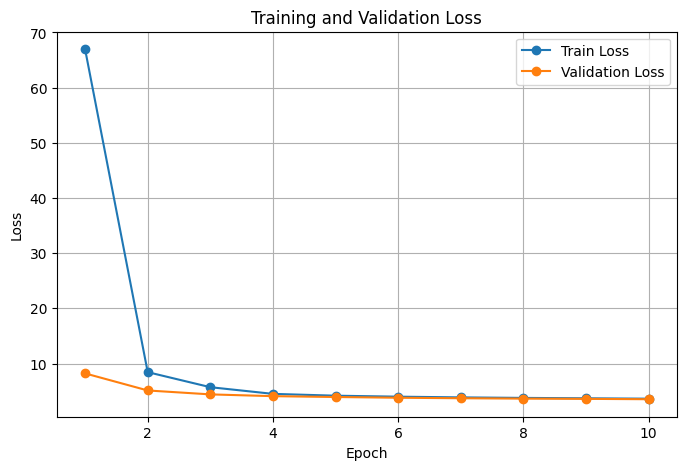

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(history["train_loss"]) + 1
    ),
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(
        1,
        len(history["val_loss"]) + 1
    ),
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

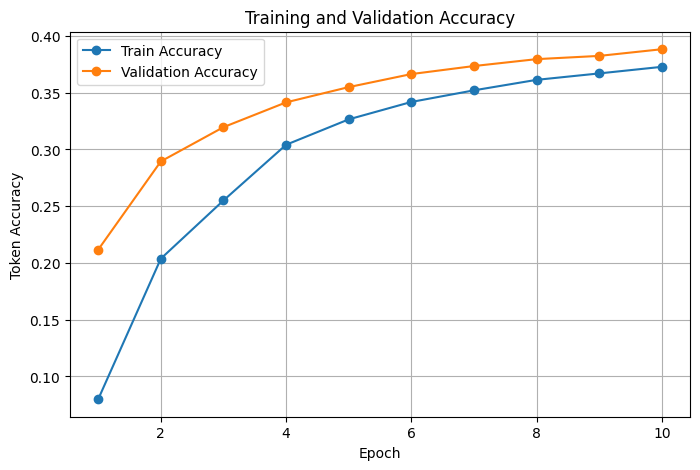

In [121]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(history["train_accuracy"]) + 1
    ),
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(
        1,
        len(history["val_accuracy"]) + 1
    ),
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Token Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [122]:
final_train_loss = history[
    "train_loss"
][-1]

final_val_loss = history[
    "val_loss"
][-1]

loss_gap = (
    final_val_loss
    - final_train_loss
)

print("최종 Train Loss:", round(final_train_loss, 4))
print("최종 Validation Loss:", round(final_val_loss, 4))
print("Loss 차이:", round(loss_gap, 4))

if loss_gap > 1.0:
    print(
        "검증 손실이 많이 높습니다. "
        "과적합 가능성이 있습니다."
    )
elif loss_gap > 0.5:
    print(
        "일부 과적합 가능성이 있으므로 "
        "생성 결과를 함께 확인해야 합니다."
    )
else:
    print(
        "Train과 Validation Loss 차이가 "
        "비교적 안정적입니다."
    )

최종 Train Loss: 3.6303
최종 Validation Loss: 3.5312
Loss 차이: -0.099
Train과 Validation Loss 차이가 비교적 안정적입니다.


In [123]:
assert os.path.exists(
    BEST_MODEL_PATH
)

print("=" * 60)
print("Transformer 챗봇 학습 완료")
print("=" * 60)

print("최적 Validation Loss:", best_val_loss)
print("학습된 Epoch:", len(history["train_loss"]))
print("최종 Batch Size:", BATCH_SIZE)
print("Warmup Steps:", WARMUP_STEPS)
print("모델 저장 경로:", BEST_MODEL_PATH)

Transformer 챗봇 학습 완료
최적 Validation Loss: 3.5312170452541776
학습된 Epoch: 10
최종 Batch Size: 64
Warmup Steps: 1000
모델 저장 경로: /content/best_chatbot_transformer.pt


## Step 6-3. 챗봇 답변 생성

학습된 Transformer에 새로운 질문을 입력하고, Decoder가 `<start>` 토큰부터 한 토큰씩 답변을 생성하도록 한다.

각 시점에서 가장 확률이 높은 토큰을 선택하는 Greedy Decoding을 사용하며, `<end>` 토큰이 생성되면 답변 생성을 종료한다.

In [124]:
def encode_question(sentence):
    sentence = preprocess_sentence(sentence)

    tokens = mecab.morphs(sentence)

    token_ids = [
        word_to_index.get(token, UNK_ID)
        for token in tokens
    ]

    token_ids = token_ids[:MAX_QUE_LEN]

    if len(token_ids) < MAX_QUE_LEN:
        token_ids += [PAD_ID] * (
            MAX_QUE_LEN - len(token_ids)
        )

    question_tensor = torch.tensor(
        [token_ids],
        dtype=torch.long,
        device=device
    )

    return question_tensor, tokens

In [125]:
def decode_answer_ids(token_ids):
    tokens = []

    for token_id in token_ids:
        token_id = int(token_id)

        if token_id == END_ID:
            break

        if token_id in {
            PAD_ID,
            START_ID
        }:
            continue

        token = index_to_word.get(
            token_id,
            UNK_TOKEN
        )

        if token != UNK_TOKEN:
            tokens.append(token)

    return " ".join(tokens)

In [126]:
def generate_answer(
    sentence,
    model,
    max_len=MAX_ANS_LEN
):
    model.eval()

    src, question_tokens = encode_question(
        sentence
    )

    generated = torch.tensor(
        [[START_ID]],
        dtype=torch.long,
        device=device
    )

    predicted_ids = []

    with torch.no_grad():
        for _ in range(max_len - 1):
            enc_mask, dec_enc_mask, dec_mask = (
                generate_masks(
                    src,
                    generated
                )
            )

            predictions, _, _, _ = model(
                src,
                generated,
                enc_mask,
                dec_enc_mask,
                dec_mask
            )

            next_token_id = predictions[
                0,
                -1
            ].argmax(dim=-1).item()

            if next_token_id == END_ID:
                break

            if next_token_id not in {
                PAD_ID,
                START_ID
            }:
                predicted_ids.append(
                    next_token_id
                )

            next_token = torch.tensor(
                [[next_token_id]],
                dtype=torch.long,
                device=device
            )

            generated = torch.cat(
                [generated, next_token],
                dim=1
            )

    answer = decode_answer_ids(
        predicted_ids
    )

    return answer

In [127]:
test_question = "오늘 너무 피곤해."

test_answer = generate_answer(
    test_question,
    transformer
)

print("질문:", test_question)
print("답변:", test_answer)

질문: 오늘 너무 피곤해.
답변: 저 도 좋 은 사람 이 에요 .


In [128]:
project_questions = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

project_answers = []

for idx, question in enumerate(
    project_questions,
    start=1
):
    answer = generate_answer(
        question,
        transformer
    )

    project_answers.append(answer)

    print(f"{idx}. 질문: {question}")
    print(f"   답변: {answer}")
    print("-" * 70)

1. 질문: 지루하다, 놀러가고 싶어.
   답변: 저 도 좋 은 사람 이 에요 .
----------------------------------------------------------------------
2. 질문: 오늘 일찍 일어났더니 피곤하다.
   답변: 좋 은 사람 이 에요 .
----------------------------------------------------------------------
3. 질문: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 좋 은 사람 이 있 을 거 예요 .
----------------------------------------------------------------------
4. 질문: 집에 있는다는 소리야.
   답변: 저 도 좋 은 사람 이 네요 .
----------------------------------------------------------------------


In [129]:
additional_questions = [
    "오늘 기분이 너무 좋아.",
    "친구랑 싸워서 속상해.",
    "시험을 망친 것 같아.",
    "배가 너무 고파.",
    "내일 여행을 가기로 했어.",
    "요즘 잠이 잘 안 와.",
    "나 혼자인 것 같아.",
    "취업 준비가 너무 힘들어.",
    "오늘 비가 많이 오네.",
    "주말에 뭐 하지?"
]

for question in additional_questions:
    answer = generate_answer(
        question,
        transformer
    )

    print("질문:", question)
    print("챗봇:", answer)
    print("-" * 70)

질문: 오늘 기분이 너무 좋아.
챗봇: 저 도 좋 아 하 는 게 좋 아요 .
----------------------------------------------------------------------
질문: 친구랑 싸워서 속상해.
챗봇: 좋 은 사람 이 있 을 거 예요 .
----------------------------------------------------------------------
질문: 시험을 망친 것 같아.
챗봇: 좋 은 사람 이 에요 .
----------------------------------------------------------------------
질문: 배가 너무 고파.
챗봇: 저 도 좋 은 사람 이 에요 .
----------------------------------------------------------------------
질문: 내일 여행을 가기로 했어.
챗봇: 마음 이 좋 은 사람 이 될 거 예요 .
----------------------------------------------------------------------
질문: 요즘 잠이 잘 안 와.
챗봇: 사랑 하 는 사람 이 있 어요 .
----------------------------------------------------------------------
질문: 나 혼자인 것 같아.
챗봇: 혼자 하 는 게 좋 겠 네요 .
----------------------------------------------------------------------
질문: 취업 준비가 너무 힘들어.
챗봇: 좋 은 사람 이 에요 .
----------------------------------------------------------------------
질문: 오늘 비가 많이 오네.
챗봇: 저 도 좋 은 시간 이 에요 .
----------------------------------------------------------------------
질문: 주말

In [130]:
def generate_answer_with_penalty(
    sentence,
    model,
    max_len=MAX_ANS_LEN,
    repetition_penalty=1.2,
    no_repeat_window=3
):
    model.eval()

    src, _ = encode_question(sentence)

    generated = torch.tensor(
        [[START_ID]],
        dtype=torch.long,
        device=device
    )

    predicted_ids = []

    with torch.no_grad():
        for _ in range(max_len - 1):
            enc_mask, dec_enc_mask, dec_mask = (
                generate_masks(
                    src,
                    generated
                )
            )

            predictions, _, _, _ = model(
                src,
                generated,
                enc_mask,
                dec_enc_mask,
                dec_mask
            )

            logits = predictions[
                0,
                -1
            ].clone()

            logits[PAD_ID] = float("-inf")
            logits[START_ID] = float("-inf")

            recent_tokens = predicted_ids[
                -no_repeat_window:
            ]

            for token_id in recent_tokens:
                if logits[token_id] > 0:
                    logits[token_id] /= repetition_penalty
                else:
                    logits[token_id] *= repetition_penalty

            next_token_id = logits.argmax(
                dim=-1
            ).item()

            if next_token_id == END_ID:
                break

            predicted_ids.append(
                next_token_id
            )

            next_token = torch.tensor(
                [[next_token_id]],
                dtype=torch.long,
                device=device
            )

            generated = torch.cat(
                [generated, next_token],
                dim=1
            )

    return decode_answer_ids(
        predicted_ids
    )

In [131]:
for question in project_questions:
    basic_answer = generate_answer(
        question,
        transformer
    )

    penalty_answer = generate_answer_with_penalty(
        question,
        transformer
    )

    print("질문:", question)
    print("기본 답변:", basic_answer)
    print("반복 억제 답변:", penalty_answer)
    print("=" * 70)

질문: 지루하다, 놀러가고 싶어.
기본 답변: 저 도 좋 은 사람 이 에요 .
반복 억제 답변: 저 도 좋 은 사람 이 에요 .
질문: 오늘 일찍 일어났더니 피곤하다.
기본 답변: 좋 은 사람 이 에요 .
반복 억제 답변: 좋 은 사람 이 에요 .
질문: 간만에 여자친구랑 데이트 하기로 했어.
기본 답변: 좋 은 사람 이 있 을 거 예요 .
반복 억제 답변: 좋 은 사람 이 있 을 거 예요 .
질문: 집에 있는다는 소리야.
기본 답변: 저 도 좋 은 사람 이 네요 .
반복 억제 답변: 저 도 좋 은 사람 이 네요 .


# Step 7. 챗봇 성능 측정

검증 데이터의 정답 답변과 모델이 생성한 답변을 비교하여 BLEU Score를 계산한다.

챗봇은 하나의 질문에 여러 자연스러운 답변이 가능하므로 BLEU Score만으로 전체 성능을 판단하기 어렵다. 따라서 BLEU Score와 실제 생성 답변에 대한 정성 평가를 함께 사용한다.

In [132]:
def calculate_bleu(
    reference,
    candidate,
    weights=(0.25, 0.25, 0.25, 0.25)
):
    if len(candidate) == 0:
        return 0.0

    return sentence_bleu(
        [reference],
        candidate,
        weights=weights,
        smoothing_function=(
            SmoothingFunction().method1
        )
    )

In [133]:
def question_ids_to_sentence(token_ids):
    tokens = []

    for token_id in token_ids:
        token_id = int(token_id)

        if token_id == PAD_ID:
            continue

        token = index_to_word.get(
            token_id,
            UNK_TOKEN
        )

        if token != UNK_TOKEN:
            tokens.append(token)

    return " ".join(tokens)

In [134]:
def answer_ids_to_tokens(token_ids):
    tokens = []

    for token_id in token_ids:
        token_id = int(token_id)

        if token_id == END_ID:
            break

        if token_id in {
            PAD_ID,
            START_ID
        }:
            continue

        token = index_to_word.get(
            token_id,
            UNK_TOKEN
        )

        if token != UNK_TOKEN:
            tokens.append(token)

    return tokens

In [135]:
sample_idx = 0

sample_question = question_ids_to_sentence(
    val_enc[sample_idx].tolist()
)

reference_tokens = answer_ids_to_tokens(
    val_dec[sample_idx].tolist()
)

prediction = generate_answer_with_penalty(
    sample_question,
    transformer
)

candidate_tokens = prediction.split()

sample_bleu = calculate_bleu(
    reference_tokens,
    candidate_tokens
)

print("질문:", sample_question)
print("정답:", " ".join(reference_tokens))
print("예측:", prediction)
print("BLEU:", round(sample_bleu, 4))
print("BLEU × 100:", round(sample_bleu * 100, 2))

질문: 원래 일 은 혼나 면서 배우 는 거 야 ?
정답: 그냥 배워도 돼요 .
예측: 저 도 좋 아 하 는 게 좋 아요 .
BLEU: 0.0211
BLEU × 100: 2.11


In [136]:
def evaluate_bleu(
    model,
    enc_data,
    dec_data,
    sample_size=300,
    verbose_count=10
):
    model.eval()

    sample_size = min(
        sample_size,
        len(enc_data)
    )

    scores = []

    for idx in tqdm(
        range(sample_size),
        desc="BLEU Evaluation"
    ):
        question = question_ids_to_sentence(
            enc_data[idx].tolist()
        )

        reference_tokens = answer_ids_to_tokens(
            dec_data[idx].tolist()
        )

        prediction = generate_answer_with_penalty(
            question,
            model
        )

        candidate_tokens = prediction.split()

        score = calculate_bleu(
            reference_tokens,
            candidate_tokens
        )

        scores.append(score)

        if idx < verbose_count:
            print()
            print("질문:", question)
            print(
                "정답:",
                " ".join(reference_tokens)
            )
            print("예측:", prediction)
            print(
                "BLEU:",
                round(score, 4)
            )

    average_score = (
        sum(scores) / len(scores)
        if scores
        else 0.0
    )

    print("\n평가 문장 수:", len(scores))
    print(
        "Average Sentence BLEU:",
        round(average_score, 4)
    )
    print(
        "BLEU × 100:",
        round(average_score * 100, 2)
    )

    return average_score, scores

In [137]:
def evaluate_bleu(
    model,
    enc_data,
    dec_data,
    sample_size=300,
    verbose_count=10
):
    model.eval()

    sample_size = min(
        sample_size,
        len(enc_data)
    )

    scores = []

    for idx in tqdm(
        range(sample_size),
        desc="BLEU Evaluation"
    ):
        question = question_ids_to_sentence(
            enc_data[idx].tolist()
        )

        reference_tokens = answer_ids_to_tokens(
            dec_data[idx].tolist()
        )

        prediction = generate_answer_with_penalty(
            question,
            model
        )

        candidate_tokens = prediction.split()

        score = calculate_bleu(
            reference_tokens,
            candidate_tokens
        )

        scores.append(score)

        if idx < verbose_count:
            print()
            print("질문:", question)
            print(
                "정답:",
                " ".join(reference_tokens)
            )
            print("예측:", prediction)
            print(
                "BLEU:",
                round(score, 4)
            )

    average_score = (
        sum(scores) / len(scores)
        if scores
        else 0.0
    )

    print("\n평가 문장 수:", len(scores))
    print(
        "Average Sentence BLEU:",
        round(average_score, 4)
    )
    print(
        "BLEU × 100:",
        round(average_score * 100, 2)
    )

    return average_score, scores

In [138]:
average_bleu, bleu_scores = evaluate_bleu(
    transformer,
    val_enc,
    val_dec,
    sample_size=300,
    verbose_count=10
)

BLEU Evaluation:   0%|          | 0/300 [00:00<?, ?it/s]


질문: 원래 일 은 혼나 면서 배우 는 거 야 ?
정답: 그냥 배워도 돼요 .
예측: 저 도 좋 아 하 는 게 좋 아요 .
BLEU: 0.0211

질문: 텅 빔
정답: 곧바로 채워질 거 예요 .
예측: 저 도 좋 겠 어요 .
BLEU: 0.0408

질문: 썸남 이 술 상태 로 고백 함 . 기억 할까 ?
정답: 기억 하 냐고 물 어 보 세요 .
예측: 좋 은 사람 이 에요 .
BLEU: 0.0293

질문: 미련 으로 붙잡 아선 안 되 겠 죠
정답: 미련 은 또 다른 후회 만 남길 뿐 이 에요 .
예측: 마음 이 되 겠 네요 .
BLEU: 0.0211

질문: 가슴 에 구멍 이 너무 커 .
정답: 아무 생각 하 지 말 고 푹 주무세요 .
예측: 저 도 좋 은 사람 이 에요 .
BLEU: 0.0245

질문: 정말 왜 이러 는 걸까
정답: 사람 영혼 은 알 기 어렵 죠 .
예측: 마음 이 남 았 어요 .
BLEU: 0.0293

질문: 자꾸 날 칭찬 하 는 여자 애 . 나 한테 관심 있 는 거 아니 야 ?
정답: 이제 상대방 을 칭찬 할 차례 인 듯 합니다 .
예측: 좋 은 사람 이 있 을 거 예요 .
BLEU: 0.0255

질문: 지속 그리워
정답: 그리워 만 하 지 말 고 연락 해 보 세요 .
예측: 좋 은 사람 이 에요 .
BLEU: 0.0177

질문: 좋 아 하 지만 힘들 어서 재혼 자고 먼저 얘기 했 어
정답: 힘든 고백 이 었 겠 네요 .
예측: 좋 은 사람 이 에요 .
BLEU: 0.0411

질문: 사랑 해서 헤어지 는 게 말 이 된다고 생각 해 ?
정답: 그 여인 을 위하 는 거 라고 생각 하 면 가능 하 다고 생가 해요 .
예측: 사랑 하 는 게 좋 을 거 예요 .
BLEU: 0.0165

평가 문장 수: 300
Average Sentence BLEU: 0.0331
BLEU × 100: 3.31


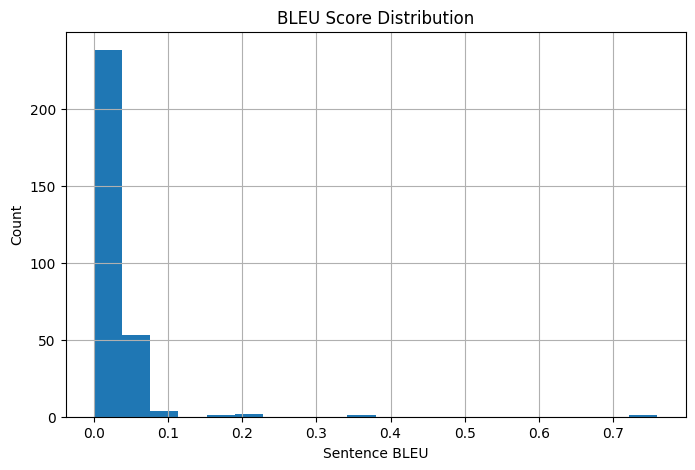

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    bleu_scores,
    bins=20
)

plt.xlabel("Sentence BLEU")
plt.ylabel("Count")
plt.title("BLEU Score Distribution")
plt.grid()
plt.show()

In [140]:
def evaluate_custom_question(
    question,
    reference_answer,
    model
):
    prediction = generate_answer_with_penalty(
        question,
        model
    )

    reference_tokens = mecab.morphs(
        preprocess_sentence(
            reference_answer
        )
    )

    candidate_tokens = prediction.split()

    bleu = calculate_bleu(
        reference_tokens,
        candidate_tokens
    )

    print("질문:", question)
    print("기준 답변:", reference_answer)
    print("모델 답변:", prediction)
    print("BLEU:", round(bleu, 4))
    print("BLEU × 100:", round(bleu * 100, 2))

    return bleu

In [141]:
evaluate_custom_question(
    question="오늘 너무 피곤해.",
    reference_answer="오늘은 일찍 쉬는 게 좋겠어요.",
    model=transformer
)

질문: 오늘 너무 피곤해.
기준 답변: 오늘은 일찍 쉬는 게 좋겠어요.
모델 답변: 저 도 좋 은 사람 이 에요 .
BLEU: 0.0285
BLEU × 100: 2.85


0.02846946938149362

In [142]:
final_project_answers = []

for question in project_questions:
    answer = generate_answer_with_penalty(
        question,
        transformer
    )

    final_project_answers.append(answer)

print("=" * 70)
print("Translations")
print("=" * 70)

for idx, answer in enumerate(
    final_project_answers,
    start=1
):
    print(f"{idx}. {answer}")

print("\n" + "=" * 70)
print("Hyperparameters")
print("=" * 70)

print(
    "n_layers:",
    MODEL_CONFIG["n_layers"]
)
print(
    "d_model:",
    MODEL_CONFIG["d_model"]
)
print(
    "n_heads:",
    MODEL_CONFIG["n_heads"]
)
print(
    "d_ff:",
    MODEL_CONFIG["d_ff"]
)
print(
    "dropout:",
    MODEL_CONFIG["dropout"]
)

print("\n" + "=" * 70)
print("Training Parameters")
print("=" * 70)

print("Warmup Steps:", WARMUP_STEPS)
print("Batch Size:", BATCH_SIZE)
print("Epoch At:", len(history["train_loss"]))
print("Best Validation Loss:", best_val_loss)
print("Average BLEU:", average_bleu)

Translations
1. 저 도 좋 은 사람 이 에요 .
2. 좋 은 사람 이 에요 .
3. 좋 은 사람 이 있 을 거 예요 .
4. 저 도 좋 은 사람 이 네요 .

Hyperparameters
n_layers: 2
d_model: 256
n_heads: 8
d_ff: 1024
dropout: 0.2

Training Parameters
Warmup Steps: 1000
Batch Size: 64
Epoch At: 10
Best Validation Loss: 3.5312170452541776
Average BLEU: 0.03305980033501892


# 최종 결과

## 1. 데이터 전처리 결과

원본 ChatbotData.csv에서 질문과 답변 데이터를 불러온 뒤 다음 전처리를 수행하였다.

- 영문자 소문자 변환
- 한글, 영문자, 숫자, 주요 문장부호 외 문자 제거
- 연속 공백 제거
- MeCab 형태소 분석
- 최대 토큰 길이 초과 문장 제거
- 중복 질문과 중복 답변 제거
- 질문과 답변의 병렬 관계 유지

전처리 후 총 7,683개의 질문-답변 쌍을 확보하였다.

## 2. 데이터 증강 결과

한국어 Word2Vec 임베딩 모델을 활용하여 Lexical Substitution을 적용하였다.

다음 세 종류의 데이터를 구성하였다.

1. 원본 질문 + 원본 답변
2. 증강 질문 + 원본 답변
3. 원본 질문 + 증강 답변

이를 통해 학습 데이터를 원본의 3배로 확장하였으며, 최종적으로 총 23,049개의 질문-답변 데이터를 구축하였다.

## 3. 모델 구성

Transformer Encoder-Decoder 구조를 사용하였다.

질문과 답변이 모두 한국어이므로 다음 부분의 가중치를 공유하였다.

- Encoder Embedding
- Decoder Embedding
- 최종 출력 Linear Layer

### Hyperparameters

- Encoder/Decoder Layer: 2
- Model Dimension: 256
- Attention Head: 8
- Feed Forward Dimension: 1024
- Dropout: 0.2
- Batch Size: 64
- Warmup Steps: 1,000
- Training Epoch: 10
- Optimizer: Adam

최종 Best Validation Loss는 3.5312로 측정되었다.

## 4. 주어진 예문에 대한 생성 결과

1. 질문: 지루하다, 놀러가고 싶어.  
   답변: 저 도 좋 은 사람 이 에요 .

2. 질문: 오늘 일찍 일어났더니 피곤하다.  
   답변: 좋 은 사람 이 에요 .

3. 질문: 간만에 여자친구랑 데이트 하기로 했어.  
   답변: 좋 은 사람 이 있 을 거 예요 .

4. 질문: 집에 있는다는 소리야.  
   답변: 저 도 좋 은 사람 이 네요 .

## 5. 성능 평가

검증 데이터의 정답 답변과 모델 생성 답변을 비교하여 Sentence BLEU Score를 계산하였다.

- Average Sentence BLEU: 0.0331
- BLEU × 100: 3.31

BLEU Score가 낮게 측정되었으며, 실제 생성 결과에서도 서로 다른 질문에 대해 좋은 사람과 관련된 비슷한 답변이 반복적으로 생성되었다.

이는 모델이 질문의 구체적인 의미를 충분히 구분하지 못하고, 학습 데이터에서 자주 등장하는 일반적인 답변 형태에 의존한 것으로 해석할 수 있다.

챗봇은 하나의 질문에 여러 자연스러운 답변이 가능하기 때문에 BLEU Score만으로 전체 성능을 평가하기는 어렵다. 그러나 이번 결과에서는 BLEU Score뿐 아니라 실제 답변의 질문 적합성도 낮았으므로 모델의 추가 개선이 필요하다.

# 결론

이번 프로젝트에서는 한국어 질문-답변 데이터와 Transformer를 활용하여 한국어 챗봇을 구현하였다.

먼저 문장 정제와 MeCab 형태소 분석을 수행하고, 중복 문장과 최대 토큰 길이를 초과한 문장을 제거하였다. 이 과정에서 질문과 답변을 하나의 쌍으로 처리하여 두 데이터의 병렬 관계가 유지되도록 하였다.

전처리 결과 총 7,683개의 질문-답변 쌍을 확보하였다. 이후 한국어 Word2Vec 임베딩을 활용한 Lexical Substitution을 질문과 답변에 각각 적용하였다. 원본 데이터, 질문 증강 데이터, 답변 증강 데이터를 결합하여 최종적으로 23,049개의 데이터를 구축하였다.

모델은 질문을 Encoder 입력으로 사용하고 답변을 Decoder 출력으로 사용하는 Transformer 구조로 구현하였다. 질문과 답변이 모두 한국어이므로 Encoder와 Decoder의 Embedding을 공유하고, 최종 출력층의 가중치도 Embedding과 공유하였다.

학습은 2개의 Encoder·Decoder Layer, 256차원의 모델, 8개의 Attention Head, 1,024차원의 Feed Forward Network를 사용하여 10 Epoch 동안 진행하였다. 최종 Best Validation Loss는 3.5312로 나타났다.

모델은 모든 질문에 대해 한국어 문장 형태의 답변을 생성했지만, 서로 다른 질문에 대해 좋은 사람과 관련된 유사한 표현을 반복하였다. 이는 모델이 질문의 세부 의미를 충분히 학습하지 못하고, 자주 등장하는 일반적인 답변 패턴에 편향된 것으로 볼 수 있다.

평균 Sentence BLEU Score는 0.0331, 백분율 기준으로 3.31점이었다. 챗봇 답변은 정답이 하나로 정해져 있지 않기 때문에 BLEU Score가 낮을 수 있지만, 실제 생성 답변에서도 질문과의 관련성이 부족하게 나타났으므로 현재 모델의 성능은 제한적인 것으로 판단하였다.

이번 프로젝트를 통해 데이터 전처리, 형태소 분석, 데이터 증강, Transformer 구현, 학습, 문장 생성 및 BLEU 평가까지 자연어 처리 모델 개발의 전체 과정을 수행할 수 있었다.

# 회고

이번 프로젝트를 통해 번역기와 챗봇이 모두 Encoder-Decoder 구조를 활용할 수 있다는 점을 확인하였다. 번역기는 입력 언어를 다른 언어로 변환하지만, 챗봇은 질문을 적절한 답변으로 변환한다는 차이가 있을 뿐 전체적인 문장 생성 과정은 유사하였다.

가장 중요했던 부분은 질문과 답변의 병렬 관계를 유지하는 것이었다. 길이 제한과 중복 제거 과정에서 질문 또는 답변만 따로 삭제하면 데이터의 대응 관계가 깨질 수 있으므로 모든 처리를 질문-답변 쌍 단위로 수행하였다.

Lexical Substitution을 활용하여 데이터를 7,683개에서 23,049개로 증가시킬 수 있었다. 다만 Word2Vec에서 가까운 단어가 항상 문맥상 자연스러운 동의어는 아니기 때문에, 일부 증강 데이터는 원래 문장의 의미를 충분히 유지하지 못했을 가능성이 있다.

특히 답변을 증강한 데이터는 질문에 대한 정답 자체를 변경할 수 있다. 의미가 부정확하게 변한 답변을 학습하면 모델이 질문과 답변의 관계보다 일반적인 단어 조합을 학습할 가능성이 있다. 향후에는 답변 증강 비율을 줄이거나 질문 데이터만 증강하는 실험이 필요하다.

최종 생성 결과에서는 서로 다른 질문에도 좋은 사람과 관련된 비슷한 답변이 반복되었다. 이는 모델이 학습 데이터에서 빈도가 높은 안전하고 일반적인 답변을 선택하는 현상으로 볼 수 있다. 이러한 현상은 생성형 모델에서 나타나는 답변 편향 또는 일반 답변 집중 문제와 관련이 있다.

향후에는 다음과 같은 방법으로 모델을 개선할 수 있다.

- 답변보다 질문 중심으로 데이터 증강 적용
- 동일 품사의 단어만 교체하도록 품사 정보 활용
- 증강 데이터의 의미 적절성 검사
- 빈도가 지나치게 높은 답변의 중복 제한
- 모델 차원과 Layer 수 조정
- Epoch 증가와 학습률 재조정
- Label Smoothing 적용
- Beam Search 또는 Top-k Sampling 적용
- 반복 토큰 및 반복 문장 패널티 강화
- BLEU 외에 의미 유사도 기반 평가 추가
- 사전 학습된 한국어 언어 모델 활용

이번 프로젝트의 결과가 완전히 자연스러운 챗봇 수준에는 도달하지 못했지만, 낮은 BLEU Score와 반복 답변이 나타난 원인을 분석하면서 데이터 품질과 모델 학습 방식이 생성 결과에 직접적인 영향을 준다는 점을 확인할 수 있었다.

In [143]:
print("=" * 70)
print("최종 프로젝트 결과")
print("=" * 70)

print("\n[데이터]")
print("전처리 후 데이터:", len(que_corpus))
print("증강 후 데이터:", len(aug_que_corpus))
print(
    "데이터 증가 배율:",
    round(len(aug_que_corpus) / len(que_corpus), 2)
)

print("\n[모델 설정]")
for key, value in MODEL_CONFIG.items():
    print(f"{key}: {value}")

print("Warmup Steps:", WARMUP_STEPS)
print("Batch Size:", BATCH_SIZE)
print("학습 Epoch:", len(history["train_loss"]))
print("Best Validation Loss:", round(best_val_loss, 4))

print("\n[필수 질문 답변]")

for idx, (question, answer) in enumerate(
    zip(project_questions, final_project_answers),
    start=1
):
    print(f"{idx}. 질문: {question}")
    print(f"   답변: {answer}")

print("\n[BLEU 평가]")
print("Average Sentence BLEU:", round(average_bleu, 4))
print("BLEU × 100:", round(average_bleu * 100, 2))

최종 프로젝트 결과

[데이터]
전처리 후 데이터: 7683
증강 후 데이터: 23049
데이터 증가 배율: 3.0

[모델 설정]
n_layers: 2
d_model: 256
n_heads: 8
d_ff: 1024
dropout: 0.2
Warmup Steps: 1000
Batch Size: 64
학습 Epoch: 10
Best Validation Loss: 3.5312

[필수 질문 답변]
1. 질문: 지루하다, 놀러가고 싶어.
   답변: 저 도 좋 은 사람 이 에요 .
2. 질문: 오늘 일찍 일어났더니 피곤하다.
   답변: 좋 은 사람 이 에요 .
3. 질문: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 좋 은 사람 이 있 을 거 예요 .
4. 질문: 집에 있는다는 소리야.
   답변: 저 도 좋 은 사람 이 네요 .

[BLEU 평가]
Average Sentence BLEU: 0.0331
BLEU × 100: 3.31


In [144]:
FINAL_SAVE_PATH = "/content/chatbot_project_final.pt"

torch.save(
    {
        "model_state_dict": transformer.state_dict(),
        "model_config": MODEL_CONFIG,
        "word_to_index": word_to_index,
        "index_to_word": index_to_word,
        "vocab_size": VOCAB_SIZE,
        "pad_id": PAD_ID,
        "unk_id": UNK_ID,
        "start_id": START_ID,
        "end_id": END_ID,
        "max_que_len": MAX_QUE_LEN,
        "max_ans_len": MAX_ANS_LEN,
        "best_val_loss": best_val_loss,
        "average_bleu": average_bleu,
        "history": history
    },
    FINAL_SAVE_PATH
)

print("최종 모델 저장 완료")
print("저장 경로:", FINAL_SAVE_PATH)
print(
    "파일 크기:",
    round(os.path.getsize(FINAL_SAVE_PATH) / 1024**2, 2),
    "MB"
)

최종 모델 저장 완료
저장 경로: /content/chatbot_project_final.pt
파일 크기: 21.59 MB


In [145]:
required_objects = {
    "que_corpus": que_corpus,
    "ans_corpus": ans_corpus,
    "aug_que_corpus": aug_que_corpus,
    "aug_ans_corpus": aug_ans_corpus,
    "enc_train": enc_train,
    "dec_train": dec_train,
    "transformer": transformer,
    "project_answers": final_project_answers,
    "average_bleu": average_bleu
}

print("=" * 70)
print("프로젝트 최종 점검")
print("=" * 70)

for name, value in required_objects.items():
    print(f"{name}: 준비 완료")

assert len(que_corpus) == len(ans_corpus)
assert len(aug_que_corpus) == len(aug_ans_corpus)
assert len(aug_que_corpus) == len(que_corpus) * 3
assert len(enc_train) == len(dec_train)
assert len(final_project_answers) == 4
assert os.path.exists(FINAL_SAVE_PATH)

print("\n모든 단계가 정상적으로 완료되었습니다.")

프로젝트 최종 점검
que_corpus: 준비 완료
ans_corpus: 준비 완료
aug_que_corpus: 준비 완료
aug_ans_corpus: 준비 완료
enc_train: 준비 완료
dec_train: 준비 완료
transformer: 준비 완료
project_answers: 준비 완료
average_bleu: 준비 완료

모든 단계가 정상적으로 완료되었습니다.
